# COVID-19 Case Trends, Policy Response & Short-Term Forecasting

This notebook investigates two questions using ECDC COVID-19 case data (2020-2022)
combined with a government policy-response measures dataset:

1. **Descriptively**: how did case/death trends and government interventions
   (mask mandates, closures, etc.) evolve together across countries?
2. **Predictively**: can government policy indicators, combined with recent case
   history, forecast short-term case trends? Two modeling approaches are compared -
   a PCA + MLP regressor predicting case counts directly, and an LSTM classifier
   predicting whether cases will rise or fall next week.

The notebook is structured as: data loading & cleaning -> exploratory visualization ->
building a merged modeling dataset -> PCA on country structure -> two predictive
modeling approaches, iterated and compared.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import datetime
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import random as rd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf

from keras import layers,models
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPRegressor

# \<functions\>

In [2]:
"""
Both accesed on 2025.12.02.
"data_old" (daily) from https://www.ecdc.europa.eu/en/publications-data/download-todays-data-geographic-distribution-covid-19-cases-worldwide
"data" (weekly) from https://www.ecdc.europa.eu/en/publications-data/download-historical-data-20-june-2022-weekly-number-new-reported-covid-19-cases
daily data, for the largest time interval, but only EU/EEA: https://www.ecdc.europa.eu/en/publications-data/data-daily-new-cases-covid-19-eueea-country
"""

def get_data(data, type, name, indicator='cases'):
    if name in data[type].values:
        data_temp = data[(data[type] == name) & (data['indicator'] == indicator)].copy()
        return data_temp
    else:
        return None
    
def get_data_old(data, type, name):
    if name in data[type].values:
        data_temp = data[data[type] == name].copy()
        return data_temp
    else:
        return None

In [3]:
"""
Sums up all data for a continentExp. Needed for the older dataset
"""

def data_by_continent(data_old, continent):
    data_continent = data_old[data_old['continentExp'] == continent].copy()
    data_grouped = data_continent.groupby('dateRep').sum().reset_index()
    return data_grouped

In [4]:
"""
Visualises the measures taken by a given country as a function of time.
Returns (fig, ax).
"""

def plot_country_measures(df, country,
                          figsize=(12,6), linewidth=6, cmap='tab20',
                          date_fmt='%Y-%m-%d', right_space=0.75):
    country_data = df[df['Country'] == country].copy()
    if country_data.empty:
        raise ValueError(f"No rows for country: {country}")

    measures = country_data['Response_measure'].unique()
    measure_to_y = {m: i for i, m in enumerate(measures)}
    fig, ax = plt.subplots(figsize=(figsize[0], max(figsize[1], len(measures)*0.35)))
    cmap_obj = plt.get_cmap(cmap)
    colors = [cmap_obj(i % cmap_obj.N) for i in range(len(measures))]

    for _, row in country_data.iterrows():
        y = measure_to_y[row['Response_measure']]
        ax.hlines(y, row['date_start'], row['date_end'],
                  linewidth=linewidth, color=colors[y], alpha=0.95)

    ax.set_yticks(list(measure_to_y.values()))
    ax.set_yticklabels(list(measure_to_y.keys()), fontsize='small')
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter(date_fmt))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize='small')
    ax.set_xlabel('Date')
    ax.set_ylabel('Measures')
    ax.set_title(f'COVID-19 Response Measures in {country}')
    plt.tight_layout()
    plt.subplots_adjust(right=right_space)
    return fig, ax

In [5]:
"""
Plot time series for 'country' with cases (red, left y-axis) and
deaths (black, right y-axis) and overlay the intervals for selected_measures.
If share_y_scale=True, the axes will share the same scale. Good for comparison
of cases vs deaths, (obviously) not good for any kind of data visualisation.
Returns (fig, ax).
"""

def plot_cases_with_measures(data, response_data, country,
                             selected_measures,
                             country_col='country', date_col='date',
                             cases_col='cases', deaths_col='deaths',
                             value_col='weekly_count',
                             figsize=(12,5), cmap='tab20',
                             alpha_span=0.25, alpha_patch=0.6,
                             date_fmt='%Y-%m-%d', right_space=0.25,
                             aggregate='sum',
                             share_y_scale=False):
    df = data.copy()
    resp = response_data.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    resp['date_start'] = pd.to_datetime(resp['date_start'])
    resp['date_end'] = pd.to_datetime(resp['date_end'])
    s = df[df[country_col] == country].copy()
    if s.empty:
        raise ValueError(f"No rows for country: {country} in data[{country_col}]")
    if 'indicator' in s.columns:
        pivot = s.pivot_table(index=date_col, columns='indicator', values=value_col, aggfunc=aggregate).reset_index()
        pivot.columns.name = None
        if 'cases' in pivot.columns:
            pivot = pivot.rename(columns={'cases': cases_col})
        if 'deaths' in pivot.columns:
            pivot = pivot.rename(columns={'deaths': deaths_col})
        series = pivot.sort_values(by=date_col)
    else:
        series = s.sort_values(by=date_col)

    # ensure single point per date

    if series.duplicated(subset=[date_col]).any():
        series = series.groupby(date_col, as_index=False).agg({col: 'sum' for col in series.columns if col != date_col})

    measures = resp[resp['Country'] == country].copy()

    fig, ax = plt.subplots(figsize=figsize)
    plotted_cases = False
    if cases_col in series.columns:
        ax.plot(series[date_col], series[cases_col], ".-r", label='cases')
        plotted_cases = True
    else:
        ax.plot([], [], ".-r", label='cases (missing)')
    ax2 = None
    if deaths_col in series.columns:
        ax2 = ax.twinx()
        ax2.plot(series[date_col], series[deaths_col], ".-k", label='deaths')
        ax2.set_ylabel(deaths_col, color='k')
        for tl in ax2.get_yticklabels():
            tl.set_color('k')
    else:
        ax.plot([], [], ".-k", label='deaths (missing)')

    # if share_y_scale=True, force 2nd axis to use same numeric y-limits as primary
    if share_y_scale and ax2 is not None:
        ax2.set_ylim(ax.get_ylim())

    if not measures.empty:
        measures = measures[measures['Response_measure'].isin(selected_measures)]
        if measures.empty:
            raise ValueError("None of the selected_measures found for this country")
        cmap_obj = plt.get_cmap(cmap)
        unique_measures = measures['Response_measure'].unique()
        color_map = {m: cmap_obj(i % cmap_obj.N) for i, m in enumerate(unique_measures)}
        for _, row in measures.iterrows():
            ax.axvspan(row['date_start'], row['date_end'],
                       color=color_map[row['Response_measure']], alpha=alpha_span)
        patch_handles = [Patch(facecolor=color_map[m], alpha=alpha_patch, label=m) for m in unique_measures]
    else:
        patch_handles = []

    # preferably only one legend
    handles, labels = ax.get_legend_handles_labels()
    if ax2 is not None:
        h2, l2 = ax2.get_legend_handles_labels()
        handles += h2; labels += l2
    handles += patch_handles

   
    fig.legend(handles=handles,
               bbox_to_anchor=(1.02, 0.95),
               loc='upper left',
               fontsize='small',
               bbox_transform=fig.transFigure)
    right_margin = max(0.55, min(right_space, 0.9))
    fig.subplots_adjust(right=right_margin)
    if ax2 is not None:
        try:
            ax2.spines['right'].set_position(('axes', 1.0))  # place at axes right edge
            ax2.yaxis.set_label_position('right')
            ax2.yaxis.set_ticks_position('right')
            for tl in ax2.get_yticklabels():
                tl.set_color('k')
        except Exception:
            pass

    ax.set_xlabel('Date')
    ax.set_ylabel(cases_col, color='r')
    for tl in ax.get_yticklabels():
        tl.set_color('r')
    ax.set_title(f"{value_col} in {country} with selected measures")
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter(date_fmt))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    return fig, ax

## 1. Data Loading & Cleaning

Two ECDC datasets are combined here: a **daily** case/death dataset and a **weekly**
dataset, which use different schemas and column names. Helper functions below
(`get_data`, `get_data_old`, `data_by_continent`) normalize access to both.

In [6]:
# read the older data file
data_old = pd.read_csv('data_old.csv')
data_old['dateRep'] = pd.to_datetime(data_old[['year', 'month', 'day']])

# read the newer data file
data = pd.read_csv('data_new.csv') # has column 'year_week' in format "yyyy-ww"
data[['year','week']] = data['year_week'].str.split('-', expand=True)
data['year'] = data['year'].astype(int)
data['week'] = data['week'].astype(int)
# create date = Monday of the ISO week
data['date'] = data.apply(lambda r: datetime.date.fromisocalendar(r['year'], r['week'], 1), axis=1)
data['date'] = pd.to_datetime(data['date'])

# read the response measures file
response_data = pd.read_csv('response_graphs_data_2022-08-25.csv')
response_data['date_start'] = pd.to_datetime(response_data['date_start'])
response_data['date_end'] = pd.to_datetime(response_data['date_end'])

## 2. Exploratory Visualizations

Case trends are plotted for individual countries (Hungary, US, China) and at the
continent level (Asia) to sanity-check the merged data and get a first look at
wave patterns across regions.


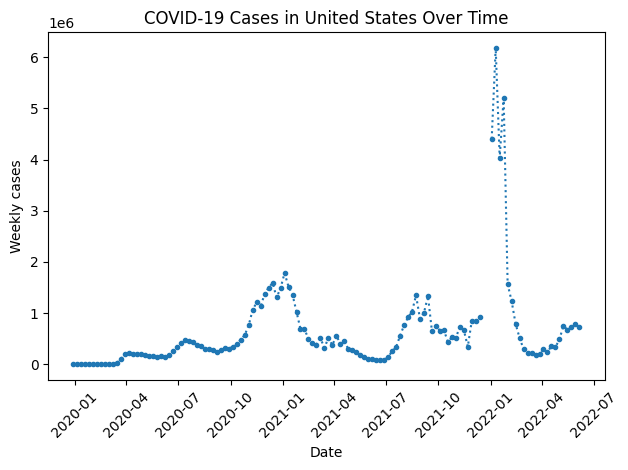

In [7]:
us_data = get_data(data, 'country', 'United States Of America', 'cases')
plt.plot(us_data['date'], us_data['weekly_count'], ".:")
plt.xlabel('Date')
plt.ylabel('Weekly cases')
plt.title('COVID-19 Cases in United States Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

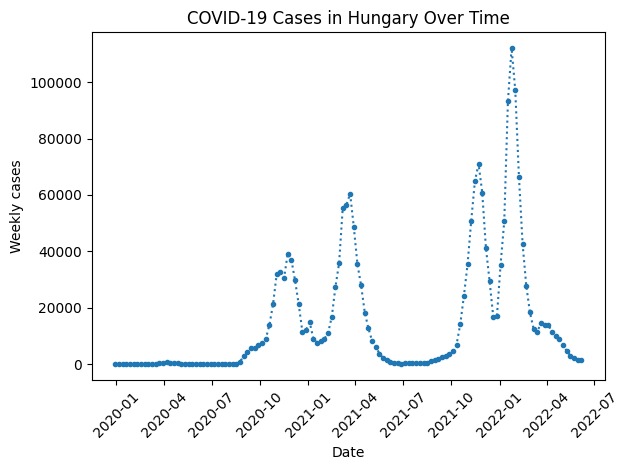

In [8]:
hu_data = get_data(data, 'country', 'Hungary')
plt.plot(hu_data['date'], hu_data['weekly_count'], ".:")
plt.xlabel('Date')
plt.ylabel('Weekly cases')
plt.title('COVID-19 Cases in Hungary Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

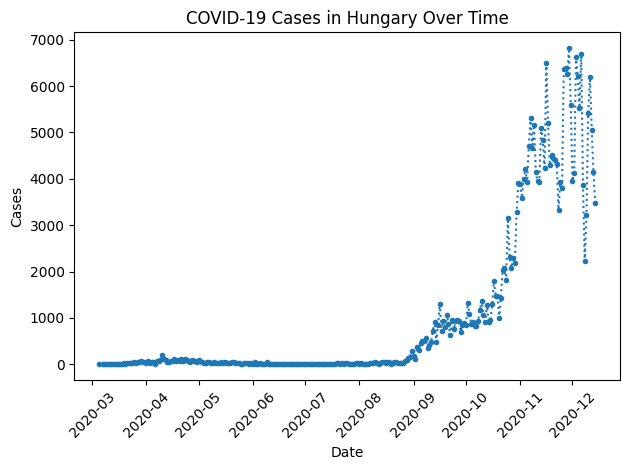

In [9]:
hu_data = get_data_old(data_old, 'countriesAndTerritories', 'Hungary')
plt.plot(hu_data['dateRep'], hu_data['cases'], ".:")
plt.xlabel('Date')
plt.ylabel('Cases')
plt.title('COVID-19 Cases in Hungary Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

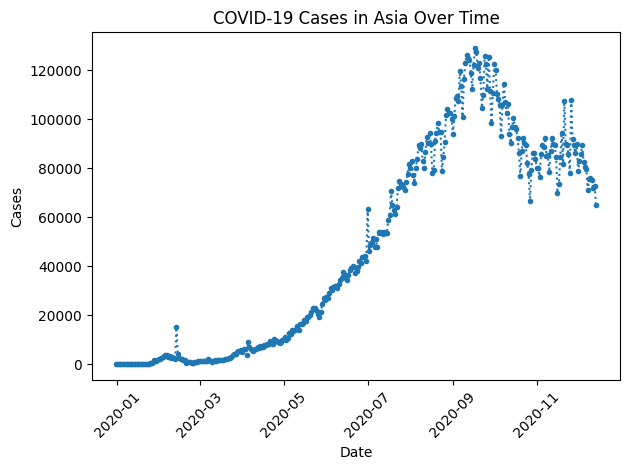

In [10]:
asia_data = data_by_continent(data_old, 'Asia')
plt.plot(asia_data['dateRep'], asia_data['cases'], ".:")
plt.xlabel('Date')
plt.ylabel('Cases')
plt.title('COVID-19 Cases in Asia Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

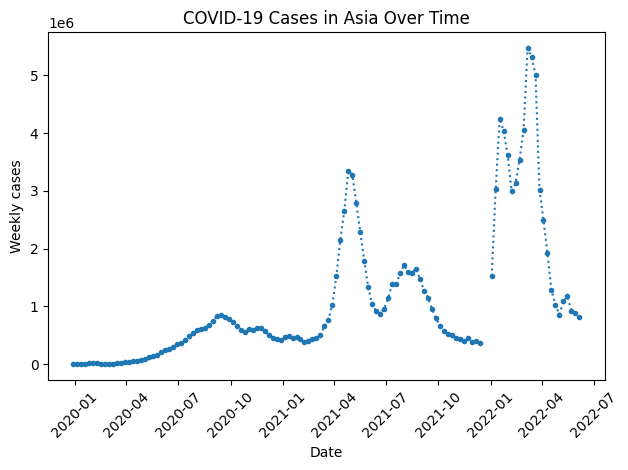

In [11]:
asia_tot_data = get_data(data, 'country', 'Asia (total)')
plt.plot(asia_tot_data['date'], asia_tot_data['weekly_count'], ".:")
plt.xlabel('Date')
plt.ylabel('Weekly cases')
plt.title('COVID-19 Cases in Asia Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

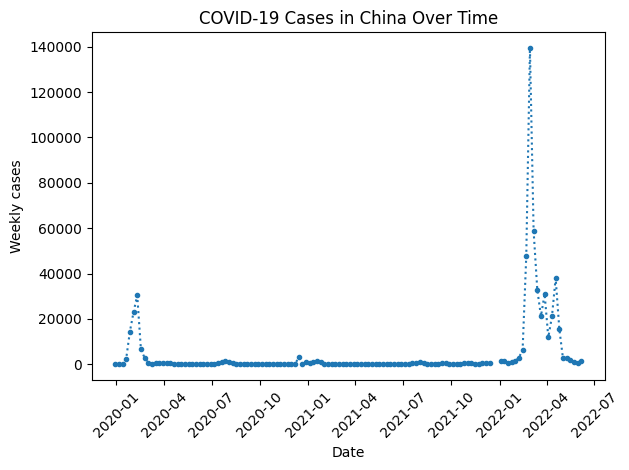

In [12]:
chn_data = get_data(data, 'country', 'China')
plt.plot(chn_data['date'], chn_data['weekly_count'], ".:")
plt.xlabel('Date')
plt.ylabel('Weekly cases')
plt.title('COVID-19 Cases in China Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

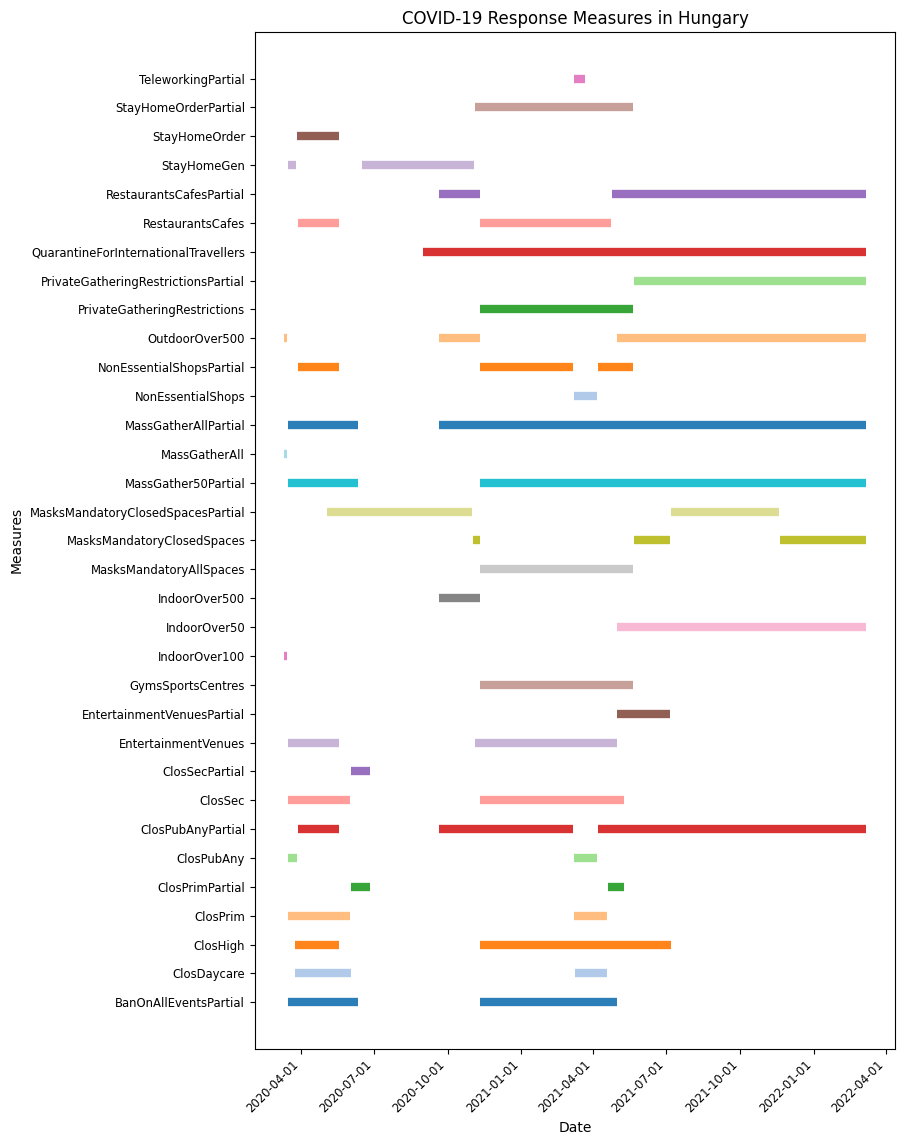

In [13]:
# example usage:
fig, ax = plot_country_measures(response_data, 'Hungary')
plt.show()

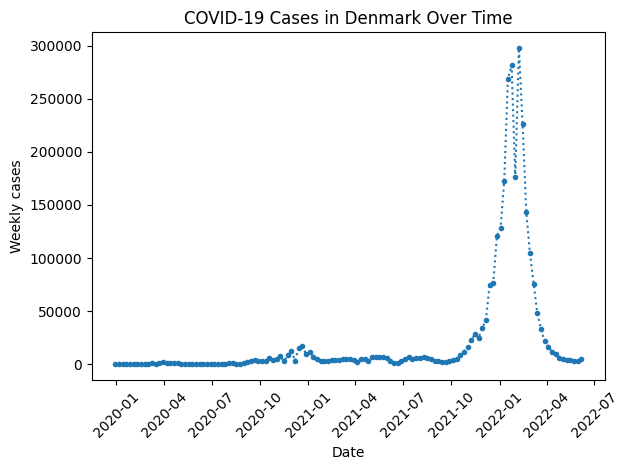

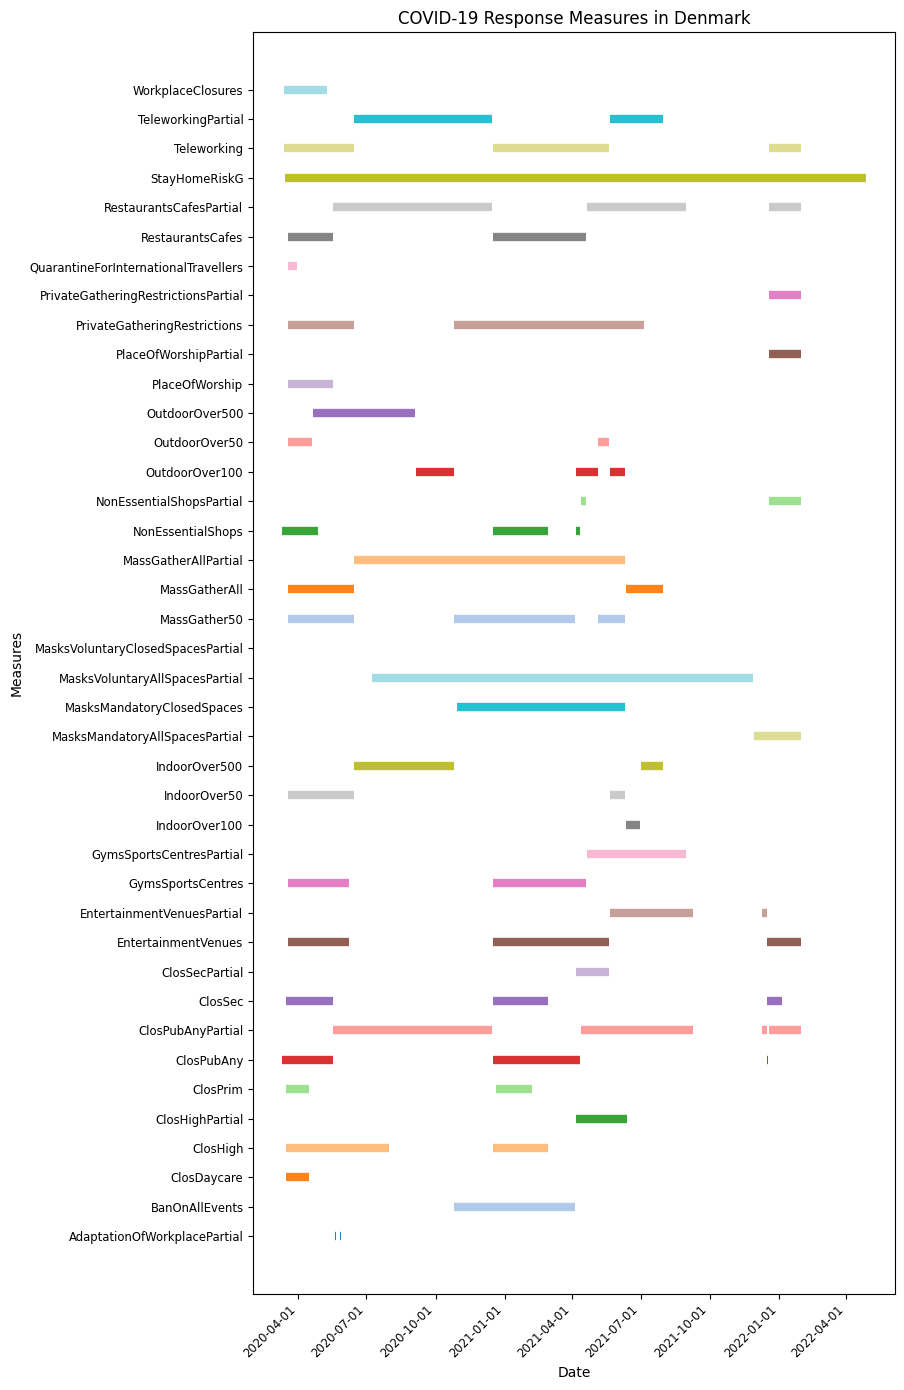

In [14]:
dnk_data = get_data(data, 'country', 'Denmark')
plt.plot(dnk_data['date'], dnk_data['weekly_count'], ".:")
# add a response measure's timeframes into this plot
plt.xlabel('Date')
plt.ylabel('Weekly cases')
plt.title('COVID-19 Cases in Denmark Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fig, ax = plot_country_measures(response_data, 'Denmark')
plt.show()

## 3. Case Trends vs. Government Response Measures

Using `plot_cases_with_measures`, case and death curves are overlaid with the periods
during which specific policy measures (mask mandates, space closures, etc.) were
active, for Denmark, Hungary, and Germany - to visually inspect whether interventions
line up with changes in case trajectory.


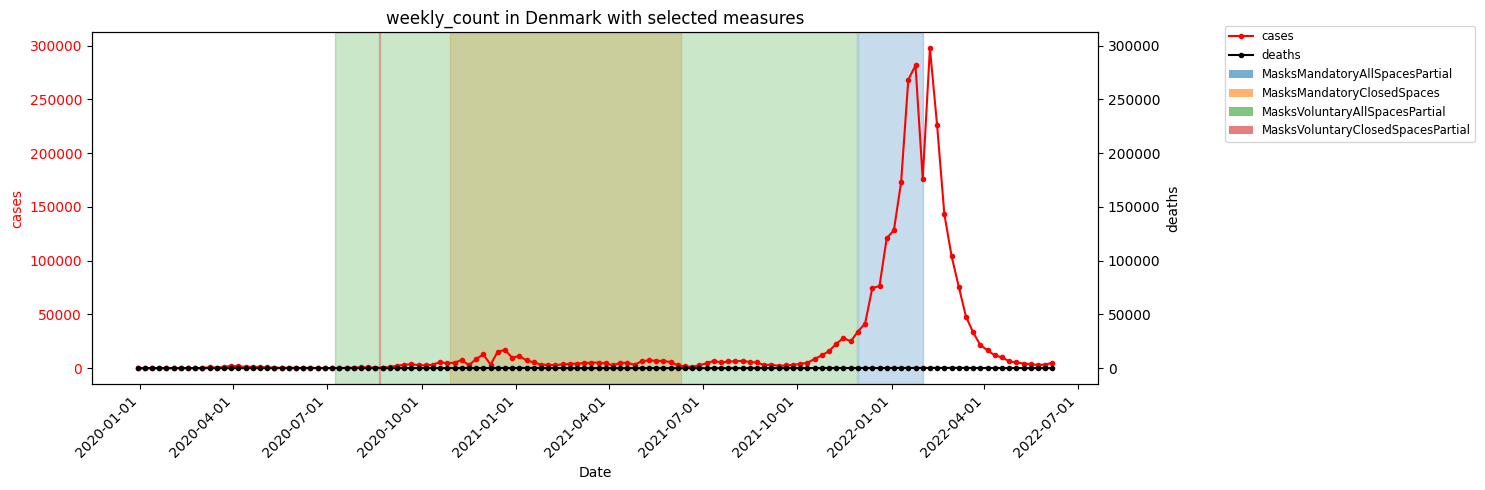

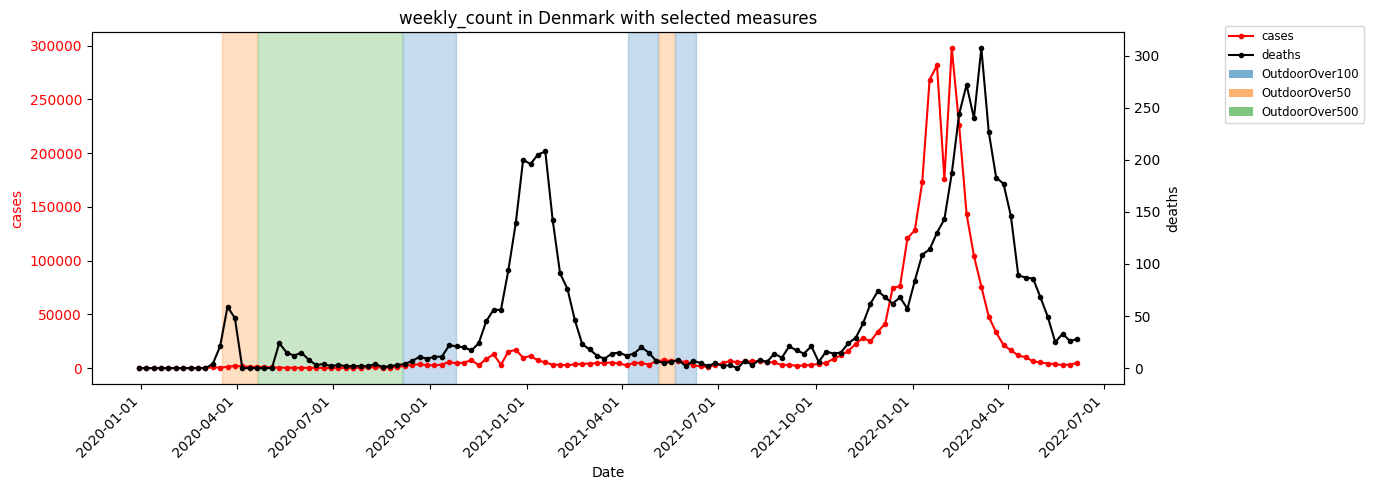

In [15]:
fig, ax = plot_cases_with_measures(data, response_data, 'Denmark',
                                  ['MasksMandatoryAllSpacesPartial',
                                   'MasksMandatoryClosedSpaces',
                                   'MasksVoluntaryAllSpacesPartial',
                                   'MasksVoluntaryClosedSpacesPartial'],
                                   cmap='tab10', share_y_scale=True)
#ax.set_xlim(pd.to_datetime(["2021-11-01", "2022-05-01"]))
plt.show()

fig, ax = plot_cases_with_measures(data, response_data, 'Denmark',
                                  ['OutdoorOver100', 'OutdoorOver50',
                                   'OutdoorOver500'], cmap='tab10',
                                   share_y_scale=False)
plt.show()



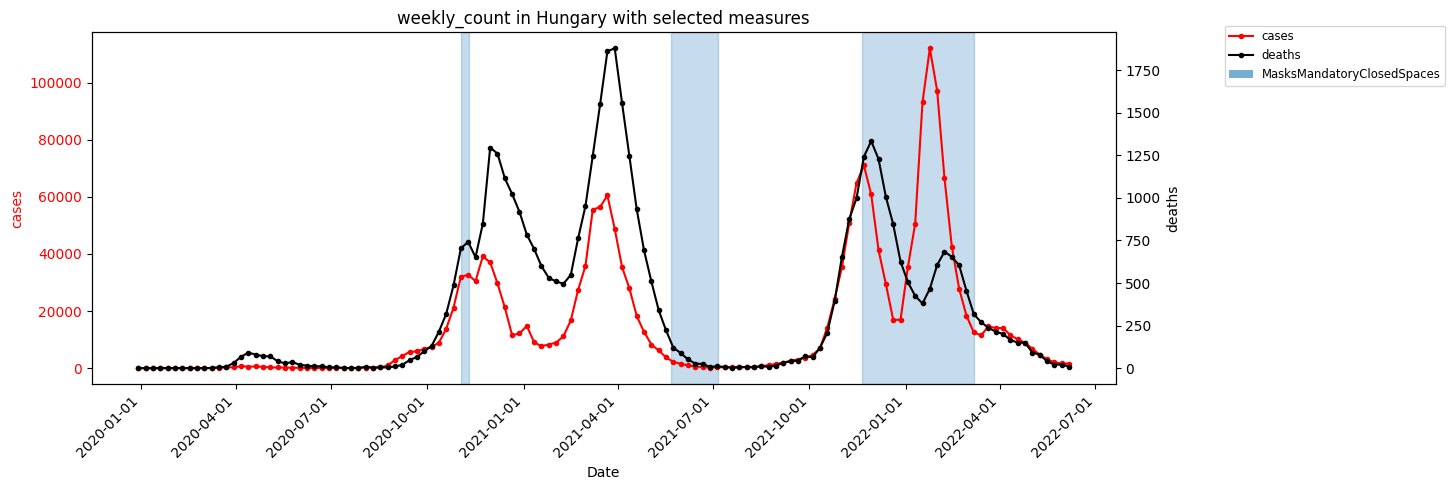

In [16]:
fig, ax = plot_cases_with_measures(data, response_data, 'Hungary',
                                  ['MasksMandatoryAllSpacesPartial',
                                   'MasksMandatoryClosedSpaces',
                                   'MasksVoluntaryAllSpacesPartial',
                                   'MasksVoluntaryClosedSpacesPartial'],
                                   cmap='tab10', share_y_scale=False)
plt.show()

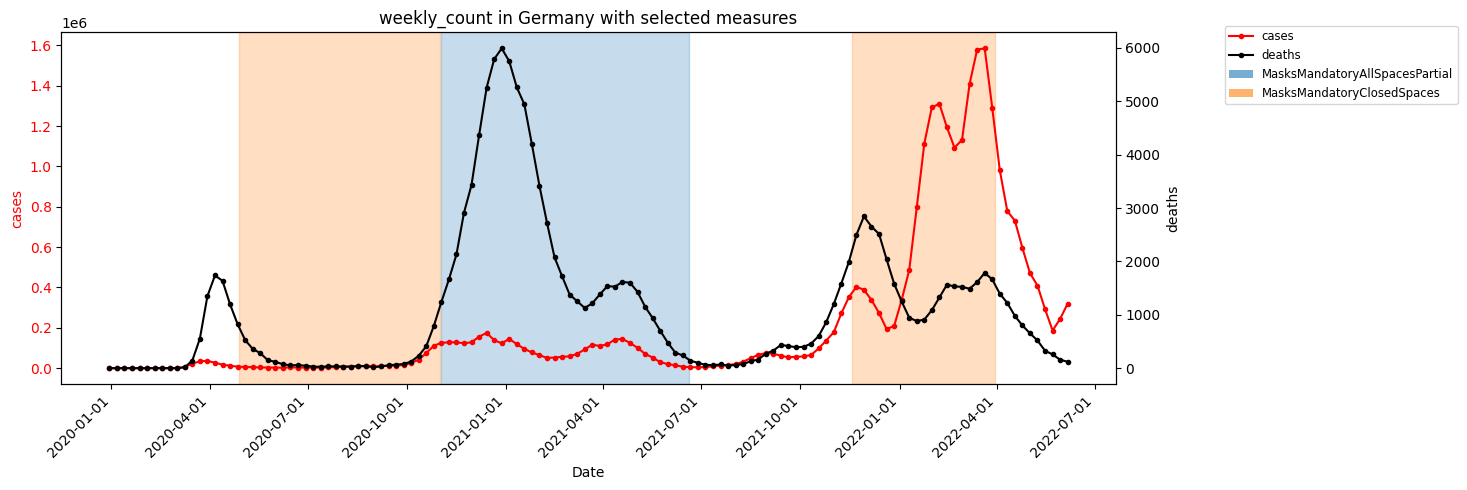

In [17]:
fig, ax = plot_cases_with_measures(data, response_data, 'Germany',
                                  ['MasksMandatoryAllSpacesPartial',
                                   'MasksMandatoryClosedSpaces',
                                   'MasksVoluntaryAllSpacesPartial',
                                   'MasksVoluntaryClosedSpacesPartial'],
                                   cmap='tab10', share_y_scale=False)
plt.show()

## 4. Building the Modeling Dataset

Policy measures are expanded from date ranges into a **weekly, one-hot encoded**
feature per (Country, week), then merged with weekly case counts and population to
produce `final_df` - the dataset used for all modeling below. This step also resolves
several data-quality issues: mismatched country name sets between the two source
datasets, malformed/swapped date ranges, and duplicate (Country, week) rows.

In [ ]:


response_data["date_start"] = pd.to_datetime(response_data["date_start"], errors="coerce")#Date formating
response_data["date_end"]   = pd.to_datetime(response_data["date_end"], errors="coerce")
data["date"] = pd.to_datetime(data["date"], errors="coerce")


countries_policy = set(response_data["Country"].dropna().unique())
countries_cases  = set(data["country"].dropna().unique())
common_countries = countries_policy.intersection(countries_cases) #Data Cleaning



response_data_filtered = response_data[response_data["Country"].isin(common_countries)].copy()#Filtering
data_filtered = data[data["country"].isin(common_countries)].copy()


before = len(response_data_filtered)
response_data_filtered = response_data_filtered.dropna(subset=["date_start", "date_end"])
after = len(response_data_filtered)



swap_mask = response_data_filtered["date_end"] < response_data_filtered["date_start"]
if swap_mask.any():
    response_data_filtered.loc[swap_mask, ["date_start", "date_end"]] = (
        response_data_filtered.loc[swap_mask, ["date_end", "date_start"]].values
    ) #Swap incorrect dates



weekday_counts = data_filtered["date"].dt.day_name().value_counts() 


if len(weekday_counts) > 0:
    most_common_day = weekday_counts.index[0]
else:
    most_common_day = "Monday"


if most_common_day == "Sunday":
    week_freq = "W-SUN"
elif most_common_day == "Monday":
    week_freq = "W-MON"
else:
    
    week_freq = "W-MON" #Data formating


rows = []
for _, row in response_data_filtered.iterrows():
    weeks = pd.date_range(
        start=row["date_start"],
        end=row["date_end"],
        freq=week_freq
    )
    for w in weeks:
        rows.append({
            "Country": row["Country"],
            "Response_measure": row["Response_measure"],
            "week": w
        })

policy_weekly = pd.DataFrame(rows)


if policy_weekly.empty:
    raise ValueError("policy_weekly is empty after filtering/expansion. Check date ranges and inputs.")


policy_features = (
    policy_weekly
    .assign(active=1)
    .pivot_table(
        index=["Country", "week"],
        columns="Response_measure",
        values="active",
        fill_value=0,
        aggfunc="max"
    )
    .reset_index()
) #Policy making


policy_features = policy_features.loc[:, ~policy_features.columns.duplicated()]


if "week" in data_filtered.columns:
    data_filtered = data_filtered.drop(columns=["week"])

cases_weekly = (
    data_filtered
    .rename(columns={"country": "Country", "date": "week"})
    [["Country", "week", "weekly_count", "population"]]
)


cases_weekly = cases_weekly.loc[:, ~cases_weekly.columns.duplicated()] #Weekly cases


dup_mask = cases_weekly.duplicated(subset=["Country", "week"], keep=False)
n_dup_rows = int(dup_mask.sum())
n_dup_groups = int(cases_weekly.loc[dup_mask, ["Country", "week"]].drop_duplicates().shape[0])
print("cases_weekly duplicate rows:", n_dup_rows, "| duplicate (Country, week) groups:", n_dup_groups)

if n_dup_rows > 0:
    cases_weekly = (
        cases_weekly
        .groupby(["Country", "week"], as_index=False)
        .agg({"weekly_count": "sum", "population": "first"})
    )
    print("cases_weekly duplicates after fix:", int(cases_weekly.duplicated(subset=["Country", "week"]).sum()))


final_df = cases_weekly.merge( #Making the final dataframe, orderly
    policy_features,
    on=["Country", "week"],
    how="left"
)


final_df = final_df.dropna(subset=["weekly_count", "population"])
print(final_df)












cases_weekly duplicate rows: 7682 | duplicate (Country, week) groups: 3841
cases_weekly duplicates after fix: 0
      Country       week  weekly_count  population  AdaptationOfWorkplace  \
0     Austria 2019-12-30           0.0     8932664                    NaN   
1     Austria 2020-01-06           0.0     8932664                    NaN   
2     Austria 2020-01-13           0.0     8932664                    NaN   
3     Austria 2020-01-20           0.0     8932664                    NaN   
4     Austria 2020-01-27           0.0     8932664                    NaN   
...       ...        ...           ...         ...                    ...   
3836   Sweden 2022-05-09        1695.0    10379295                    NaN   
3837   Sweden 2022-05-16        1858.0    10379295                    NaN   
3838   Sweden 2022-05-23        1344.0    10379295                    NaN   
3839   Sweden 2022-05-30        1279.0    10379295                    NaN   
3840   Sweden 2022-06-06        1900.0   

In [19]:
pd.set_option("display.max_columns", None) #Show all columns

final_df.head()
x_data_all=final_df.drop(columns=["weekly_count"])
x_data_all=x_data_all.to_numpy()
final_df.head()

country=final_df["Country"].unique()
k_mean=final_df.groupby("Country")["population"].mean()
k_mean=k_mean.to_numpy()


## 5. PCA: Do Countries Cluster by Case Load & Population?

A quick PCA on (weekly case count, population) checks whether countries separate
into interpretable groups along these two dimensions alone, before adding policy
features into the predictive models.

Explained variance ratio: [0.70332075 0.29667925]
Components (loadings) rows=[PC1, PC2], cols=[weekly_count, population]:
[[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]

PCA country-mean scores (first 10):
        Country       PC1       PC2
10      Germany  3.169631 -1.368661
9        France  2.778431 -0.726391
15        Italy  2.002502 -0.940821
28        Spain  1.393004 -0.760963
23       Poland  0.808353 -0.708215
21  Netherlands  0.210644  0.052039
25      Romania  0.058208 -0.215508
1       Belgium -0.146458  0.088989
24     Portugal -0.156777  0.163210
5       Czechia -0.185152  0.107926


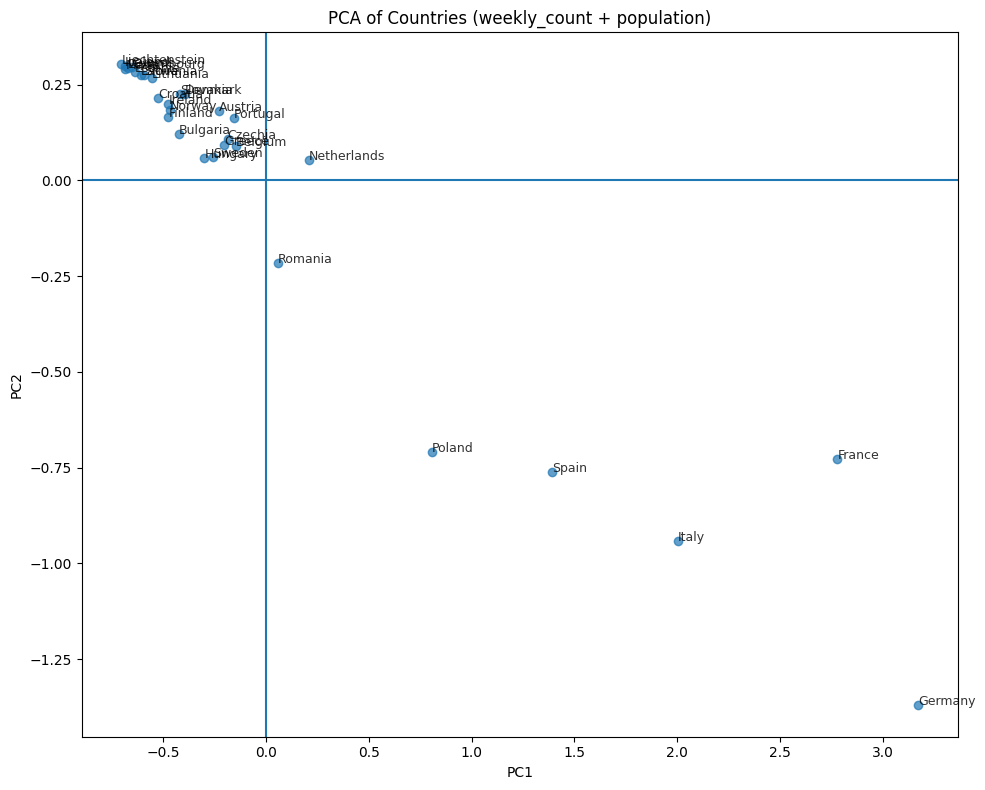

In [20]:





pca_df = final_df[["Country", "weekly_count", "population"]].copy()
pca_df = pca_df.dropna(subset=["Country", "weekly_count", "population"]) #Drop na values


pca_df["weekly_count"] = pd.to_numeric(pca_df["weekly_count"], errors="coerce") #Convert to numeric
pca_df["population"] = pd.to_numeric(pca_df["population"], errors="coerce")
pca_df = pca_df.dropna(subset=["weekly_count", "population"])


X = pca_df[["weekly_count", "population"]].to_numpy()


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=2, random_state=42)
scores = pca.fit_transform(X_scaled)


pca_scores = pca_df[["Country"]].copy()
pca_scores["PC1"] = scores[:, 0]
pca_scores["PC2"] = scores[:, 1] #Get the scores

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Components (loadings) rows=[PC1, PC2], cols=[weekly_count, population]:")
print(pca.components_)


pca_country_mean = (
    pca_scores
    .groupby("Country", as_index=False)[["PC1", "PC2"]]
    .mean()
    .sort_values("PC1", ascending=False)
)

print("\nPCA country-mean scores (first 10):")
print(pca_country_mean.head(10))
plt.figure(figsize=(10, 8))

plt.scatter(
    pca_country_mean["PC1"],
    pca_country_mean["PC2"],
    alpha=0.7
)


for _, row in pca_country_mean.iterrows():
    plt.text(
        row["PC1"],
        row["PC2"],
        row["Country"],
        fontsize=9,
        alpha=0.8
    )

plt.axhline(0)
plt.axvline(0)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Countries (weekly_count + population)")

plt.tight_layout()
plt.show()


## 6. Predictive Modeling

Two modeling approaches are compared for predicting case trends from policy-measure
history:

- **Model A - PCA + MLP Regressor**: a deliberately naive baseline. It predicts the
  *actual weekly case count* directly from policy-measure indicators alone - with
  **no memory of recent case levels** - using a country-level `GroupShuffleSplit`.
  It is included to demonstrate a point, not as a competitive model: weekly case
  counts have strong week-to-week momentum, and a model with no autoregressive
  signal at all has no way to capture that. Its poor performance (see below) is the
  expected result, not a bug.
- **Model B - LSTM Classifier**: predicts only the *direction* (up/down) of next
  week's case count from a rolling window of policy history **and** recent case
  history, evaluated across four iterations (v1-v4). A key finding that emerges
  from comparing them: versions using a **time-based** train/test split 
  struggle to generalize from the early pandemic (train) to the Delta/Omicron era
  (test) two structurally different regimes.
  Results Summary at the end of the notebook.


In [21]:
final_df.head()
country_dfs = {country: group.copy()
               for country, group in final_df.groupby("Country")}

country=final_df["Country"].unique() #Making the country list

#We choose half of the countries randomly, then we consturct the traing/validation data

test_countries=rd.sample(list(country),k=country.shape[0]//2)


In [22]:
test_data = final_df[final_df["Country"].isin(test_countries)].copy()

target_col = "weekly_count"
exclude_cols = ["Country", "week", target_col] #Making the test and train data
X_test_df = test_data.drop(columns=exclude_cols, errors="ignore")
y_test = test_data[target_col].to_numpy(dtype=float)
X_test = X_test_df.to_numpy(dtype=float)
train_countries = [c for c in country if c not in test_countries]
train_data = final_df[final_df["Country"].isin(train_countries)].copy()

target_col = "weekly_count"
exclude_cols = ["Country", "week", target_col]
X_train_df = train_data.drop(columns=exclude_cols, errors="ignore")
y_train = train_data[target_col].to_numpy(dtype=float)
X_train = X_train_df.to_numpy(dtype=float)
X_train.shape 

(1920, 66)

### Model A: PCA(2) + MLP Regressor (Naive Baseline)

**Why this model is expected to fail:** its only inputs are policy-measure
indicators, compressed to 2 components via PCA - there is no lagged case-count
feature at all. Predicting an absolute case count with no information about *last
week's* case count is close to an impossible task, since case counts are
overwhelmingly explained by their own recent history (epidemic momentum), not by
which policy measures are active on a given week. The PCA(2) bottleneck compounds
this by discarding most of the remaining policy-measure signal before the MLP even
sees it.

This is included specifically to illustrate that point-in-time regression without
any autoregressive/sequence information is not a viable approach for this kind of
data - which is exactly the gap the LSTM models below are designed to close by
including recent case history as an input feature.


Duplicate rows: 0 Duplicate (Country,week) groups: 0
Duplicates after fix: 0
Train R2: 0.01075046302211291
Test  R2: -0.027675522192813995
MAE: 75723.84049664043
RMSE: 225383.71192788825
Bias: -50264.178903947606
Median AE: 25571.853977241335


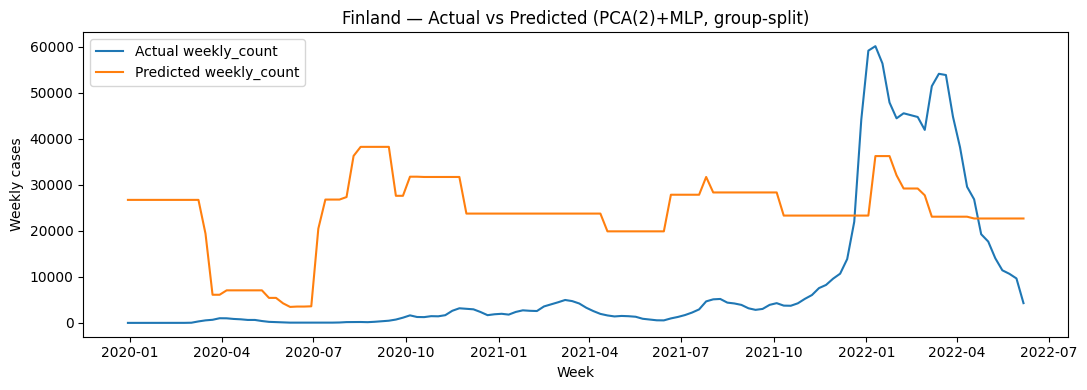

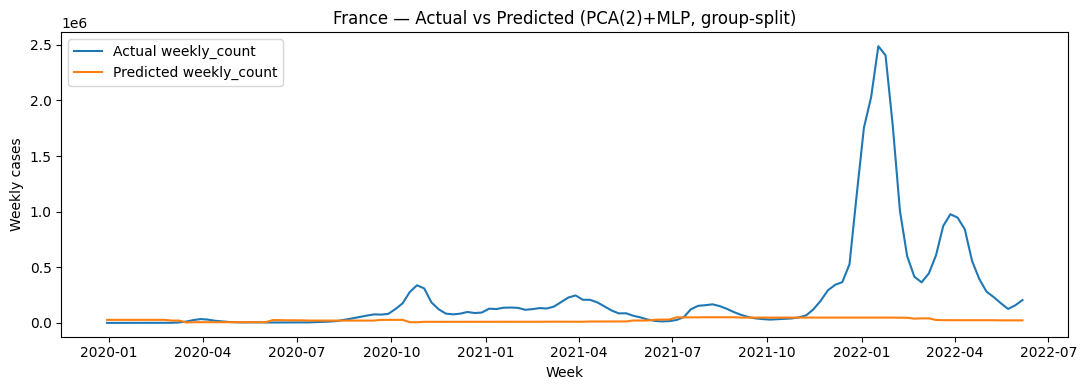

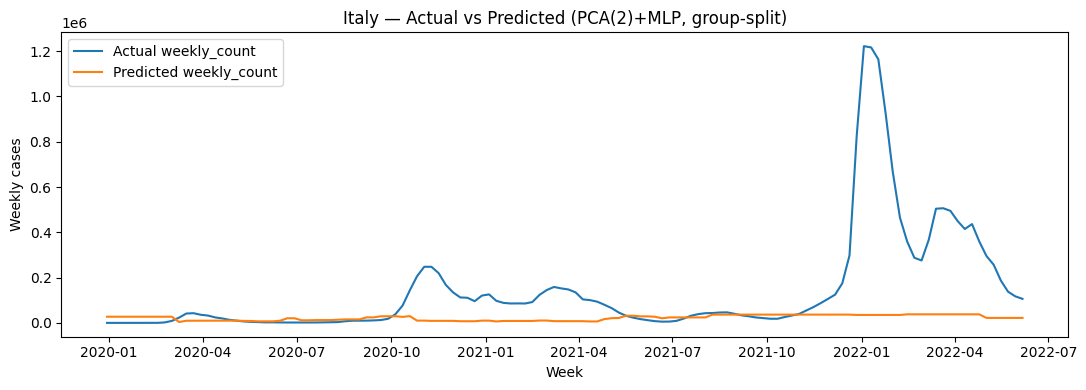

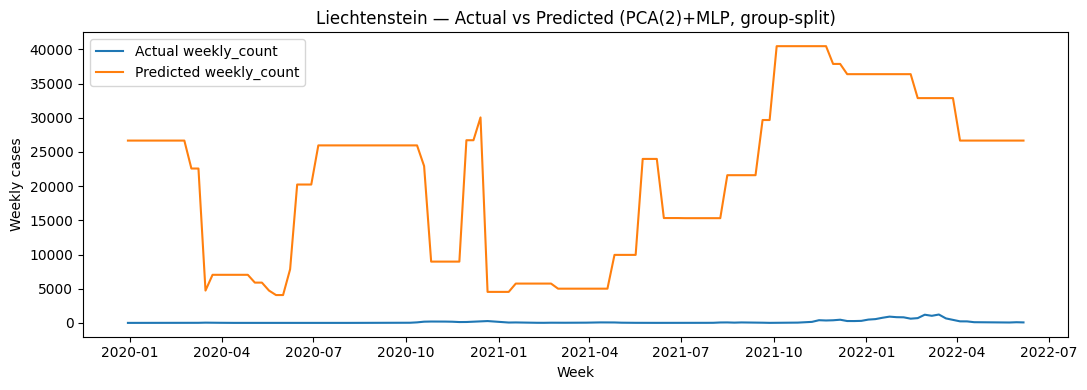

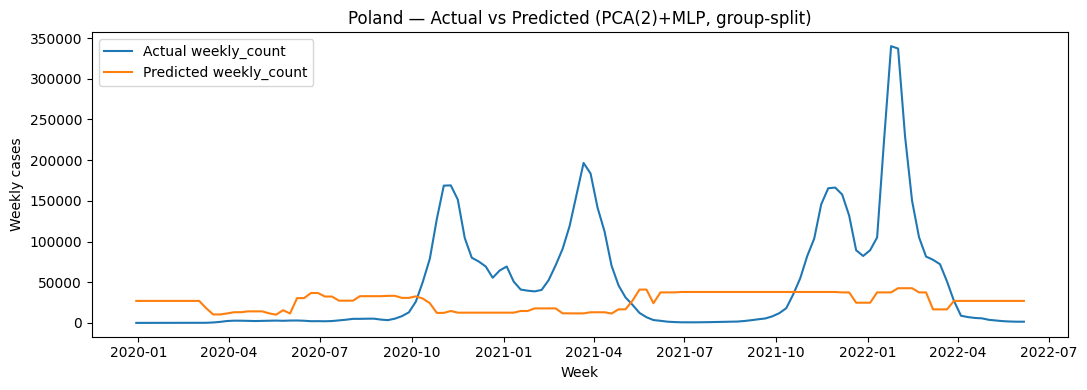

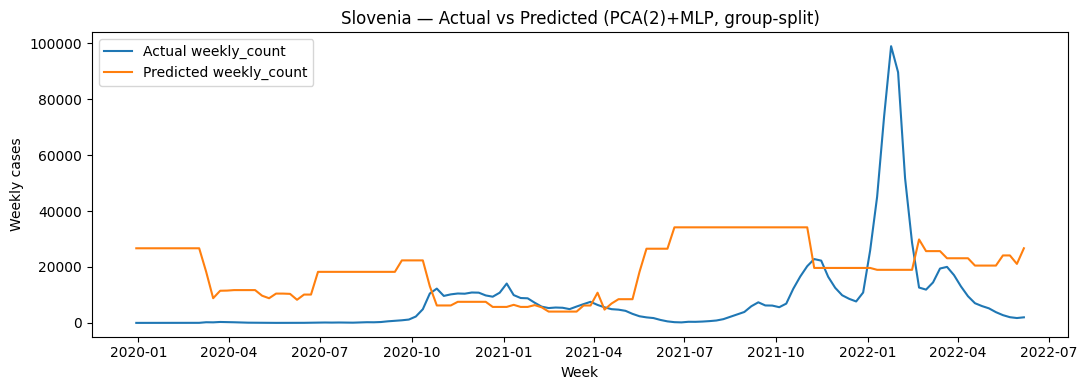

In [23]:
"Naive PCA + MLP regressor model with group shuffle split (by country)"
SEED = 42 #For reproducibility
np.random.seed(SEED)

df = final_df.copy()
df["week"] = pd.to_datetime(df["week"], errors="coerce")
df["weekly_count"] = pd.to_numeric(df["weekly_count"], errors="coerce")
df["Country"] = df["Country"].astype(str)
df = df.dropna(subset=["Country", "week", "weekly_count"]).copy()
df = df.sort_values(["Country", "week"]).reset_index(drop=True) #Sort values

key_cols = ["Country", "week"]
dup_mask = df.duplicated(subset=key_cols, keep=False)
n_dup_rows = int(dup_mask.sum())
n_dup_groups = int(df.loc[dup_mask, key_cols].drop_duplicates().shape[0])
print("Duplicate rows:", n_dup_rows, "Duplicate (Country,week) groups:", n_dup_groups)

if n_dup_rows > 0:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    other_cols = [c for c in df.columns if c not in numeric_cols]

    agg = {}
    for c in numeric_cols:
        if c == "weekly_count":
            agg[c] = "sum"
        else:
            agg[c] = "mean"

    for c in other_cols:
        if c in key_cols:
            continue
        agg[c] = "first"

    df = (
        df.groupby(key_cols, as_index=False)
          .agg(agg)
          .sort_values(key_cols)
          .reset_index(drop=True)
    ) #Fix duplicates by aggregating, beacuse we had issues with that

print("Duplicates after fix:", int(df.duplicated(subset=key_cols).sum()))

feature_cols = df.columns.difference(["Country", "week", "weekly_count"])
X = df[feature_cols].apply(pd.to_numeric, errors="coerce").to_numpy()
y = df["weekly_count"].to_numpy(dtype=float)
groups = df["Country"].to_numpy() #Groups for group shuffle split

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED) #Random split by country
train_idx, test_idx = next(gss.split(X, y, groups=groups)) #indexes

X_train_raw, X_test_raw = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx] #Test and train data

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=SEED)),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        learning_rate_init=1e-3,
        alpha=1e-4,
        max_iter=2000,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=25,
        random_state=SEED
    ))
])

model.fit(X_train_raw, y_train)

train_r2 = float(model.score(X_train_raw, y_train))
test_r2 = float(model.score(X_test_raw, y_test)) #R2 scores

y_pred = model.predict(X_test_raw)

mae = float(mean_absolute_error(y_test, y_pred)) #Metrics
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
bias = float(np.mean(y_pred - y_test))
medae = float(np.median(np.abs(y_pred - y_test)))


print("Train R2:", train_r2)
print("Test  R2:", test_r2)
print("MAE:", mae)
print("RMSE:", rmse)
print("Bias:", bias)
print("Median AE:", medae)


test_plot = df.iloc[test_idx][["Country", "week", "weekly_count"]].copy()
test_plot["predicted_weekly_count"] = y_pred
test_plot = test_plot.sort_values(["Country", "week"]).reset_index(drop=True)

for c, g in test_plot.groupby("Country", sort=True):
    g = g.sort_values("week")

    plt.figure(figsize=(11, 4))
    plt.plot(g["week"], g["weekly_count"], label="Actual weekly_count")
    plt.plot(g["week"], g["predicted_weekly_count"], label="Predicted weekly_count")
    plt.xlabel("Week")
    plt.ylabel("Weekly cases")
    plt.title(f"{c} — Actual vs Predicted (PCA(2)+MLP, group-split)")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 6a. Shared Helper Functions for Model B (LSTM Variants)

Models B v1-v4 below share the same overall pipeline (clean data -> split ->
scale -> build sliding-window sequences -> train an LSTM -> evaluate), and only
differ in a handful of choices (lookback, per-capita scaling, 
early-stopping settings). The shared logic is factored into functions here so
each version below only needs to state what's different about it.


In [24]:
def clean_country_week_data(final_df, countries, use_per_capita=False, per_capita_scale=100000.0):
    """Filter to the target countries, coerce types, drop invalid rows,
    optionally compute a per-capita case rate, and collapse duplicate
    (Country, week) rows.

    Returns (df, value_col), where `value_col` is the name of the column
    holding the case-count value to model - "weekly_count" if
    use_per_capita is False, otherwise "weekly_per_100k".
    """
    df = final_df.copy()
    df["week"] = pd.to_datetime(df["week"], errors="coerce")
    df["weekly_count"] = pd.to_numeric(df["weekly_count"], errors="coerce")
    df["Country"] = df["Country"].astype(str)

    required_cols = ["week", "weekly_count", "Country"]
    if use_per_capita:
        df["population"] = pd.to_numeric(df["population"], errors="coerce")
        required_cols.append("population")

    df = df[df["Country"].isin(countries)].copy()
    df = df.dropna(subset=required_cols).copy()
    df = df.sort_values(["Country", "week"]).reset_index(drop=True)

    if use_per_capita:
        df["weekly_per_100k"] = df["weekly_count"].astype(float) / df["population"].astype(float) * per_capita_scale
        df["weekly_per_100k"] = df["weekly_per_100k"].replace([np.inf, -np.inf], np.nan)
        df = df.dropna(subset=["weekly_per_100k"]).copy()
        value_col = "weekly_per_100k"
    else:
        value_col = "weekly_count"

    key_cols = ["Country", "week"]
    dup_mask = df.duplicated(subset=key_cols, keep=False)
    n_dup_rows = int(dup_mask.sum())
    n_dup_groups = int(df.loc[dup_mask, key_cols].drop_duplicates().shape[0])
    print("Duplicate rows:", n_dup_rows, "Duplicate (Country,week) groups:", n_dup_groups)

    if n_dup_rows > 0:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        other_cols = [c for c in df.columns if c not in numeric_cols]

        agg = {}
        for c in numeric_cols:
            if c == value_col:
                agg[c] = "sum"
            elif c == "population":
                agg[c] = "first"
            elif c == "weekly_count":
                agg[c] = "first"
            else:
                agg[c] = "mean"
        for c in other_cols:
            if c in key_cols:
                continue
            agg[c] = "first"

        df = (
            df.groupby(key_cols, as_index=False)
              .agg(agg)
              .sort_values(key_cols)
              .reset_index(drop=True)
        )

    print("Duplicates after fix:", int(df.duplicated(subset=key_cols).sum()))

    df["y"] = np.log1p(df[value_col].astype(float))
    return df, value_col


def split_by_time(df, cutoff):
    """Time-based train/test split: train on weeks before `cutoff`, test on
    weeks at or after it."""
    train_df = df[df["week"] < cutoff].copy()
    test_df = df[df["week"] >= cutoff].copy()
    if len(train_df) == 0 or len(test_df) == 0:
        raise ValueError("Empty train/test after time split. Check dates.")
    return train_df, test_df


def split_by_country(df, seed, test_frac):
    """Country-level train/test split: hold out an entire random subset of
    countries for testing, so the model is evaluated on countries never
    seen during training."""
    unique_countries = np.array(sorted(df["Country"].unique()), dtype=object)
    rng = np.random.default_rng(seed)
    n_test = max(1, int(round(test_frac * len(unique_countries))))
    test_countries = rng.choice(unique_countries, size=n_test, replace=False)
    train_countries = np.array([c for c in unique_countries if c not in set(test_countries)], dtype=object)

    print("Train countries:", list(train_countries))
    print("Test  countries:", list(test_countries))

    train_df = df[df["Country"].isin(train_countries)].copy()
    test_df = df[df["Country"].isin(test_countries)].copy()
    if len(train_df) == 0 or len(test_df) == 0:
        raise ValueError("Empty train/test after country split. Check countries.")
    return train_df, test_df, list(train_countries), list(test_countries)


def scale_measures_and_target(train_df, test_df, value_col, include_target=True):
    """Median-impute and standardize policy-measure columns (fit on train
    only). If `include_target` is True, also standardize the log-transformed
    target `y` (fit on train only) and append it to the feature columns as
    `y_in` - used by the two-head models, but not the v1 direction-only model.
    """
    excluded = {"Country", "week", "weekly_count", "weekly_per_100k", "population", "y"}
    measure_cols = [c for c in train_df.columns if c not in excluded]

    for c in measure_cols:
        if train_df[c].dtype == "object":
            train_df[c] = pd.to_numeric(train_df[c], errors="coerce")
        if test_df[c].dtype == "object":
            test_df[c] = pd.to_numeric(test_df[c], errors="coerce")

    X_train_meas = train_df[measure_cols].copy()
    X_test_meas = test_df[measure_cols].copy()

    train_medians = X_train_meas.median(numeric_only=True)
    X_train_meas = X_train_meas.fillna(train_medians)
    X_test_meas = X_test_meas.fillna(train_medians)

    scaler_meas = StandardScaler()
    X_train_meas_scaled = scaler_meas.fit_transform(X_train_meas.to_numpy(dtype=float))
    X_test_meas_scaled = scaler_meas.transform(X_test_meas.to_numpy(dtype=float))

    keep_cols = ["Country", "week", value_col] + (["y"] if include_target else [])
    train_scaled = train_df[keep_cols].copy()
    test_scaled = test_df[keep_cols].copy()
    for i, col in enumerate(measure_cols):
        train_scaled[col] = X_train_meas_scaled[:, i]
        test_scaled[col] = X_test_meas_scaled[:, i]

    feature_cols = list(measure_cols)
    if include_target:
        scaler_y = StandardScaler()
        y_train_series = train_scaled["y"].to_numpy(dtype=float).reshape(-1, 1)
        y_test_series = test_scaled["y"].to_numpy(dtype=float).reshape(-1, 1)
        train_scaled["y_in"] = scaler_y.fit_transform(y_train_series).reshape(-1)
        test_scaled["y_in"] = scaler_y.transform(y_test_series).reshape(-1)
        feature_cols = feature_cols + ["y_in"]

    return train_scaled, test_scaled, feature_cols


def make_sequences_updown(df_scaled, lookback, feature_cols, value_col):
    """Build sliding-window sequences with a simple up/down label only
    (Model B v1 baseline)."""
    X_list, y_list = [], []
    for _, g in df_scaled.groupby("Country", sort=False):
        g = g.sort_values("week").reset_index(drop=True)
        Xg = g[feature_cols].to_numpy(dtype=float)
        values = g[value_col].to_numpy(dtype=float)
        for t in range(lookback, len(g)):
            y_list.append(1.0 if values[t] > values[t - 1] else 0.0)
            X_list.append(Xg[t - lookback:t, :])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


def make_sequences_twohead(df_scaled, lookback, feature_cols, value_col, thresh_pct, min_denom=1.0):
    """Build sliding-window sequences for the two-head model: a direction
    label (value up/down vs. the previous week) and a magnitude target
    (|log-change| in value). Used by Models B v2-v4.

    `min_denom` floors the denominator in the percent-change calculation -
    1.0 for raw case counts, a much smaller value (e.g. 1e-6) for per-capita
    rates, which are small decimals.
    """
    X_list, y_dir_list, y_mag_list, meta_list = [], [], [], []
    for country, g in df_scaled.groupby("Country", sort=False):
        g = g.sort_values("week").reset_index(drop=True)
        Xg = g[feature_cols].to_numpy(dtype=float)
        values = g[value_col].to_numpy(dtype=float)
        y = g["y"].to_numpy(dtype=float)
        weeks = g["week"].to_numpy()

        for t in range(lookback, len(g)):
            prev_v = values[t - 1]
            curr_v = values[t]
            pct_change = (curr_v - prev_v) / max(prev_v, min_denom) * 100.0
            up = 1.0 if pct_change > thresh_pct else 0.0

            r = y[t] - y[t - 1]
            mag = float(np.abs(r))

            X_list.append(Xg[t - lookback:t, :])
            y_dir_list.append(up)
            y_mag_list.append(mag)
            meta_list.append((country, weeks[t], prev_v, curr_v, r))

    X = np.array(X_list, dtype=np.float32)
    y_dir = np.array(y_dir_list, dtype=np.float32).reshape(-1)
    y_mag = np.array(y_mag_list, dtype=np.float32).reshape(-1)
    meta = np.array(meta_list, dtype=object)
    return X, y_dir, y_mag, meta


def build_direction_only_lstm(lookback, n_features):
    """Single-output LSTM classifier - the Model B v1 baseline architecture."""
    model = models.Sequential([
        layers.Input(shape=(lookback, n_features)),
        layers.LSTM(32, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy")
    return model


def build_two_head_lstm(lookback, n_features, delta_huber, lambda_mag):
    """Two-head LSTM: a binary direction classifier and a magnitude
    regressor, sharing an LSTM encoder - the architecture used from
    Model B v2 onward."""
    inputs = layers.Input(shape=(lookback, n_features))
    x = layers.LSTM(32, return_sequences=True)(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(32)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation="relu")(x)

    out_dir = layers.Dense(1, activation="sigmoid")(x)
    out_mag = layers.Dense(1, activation="softplus")(x)

    model = models.Model(inputs=inputs, outputs=[out_dir, out_mag])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=["binary_crossentropy", tf.keras.losses.Huber(delta=delta_huber)],
        loss_weights=[1.0, lambda_mag],
        metrics=[
            [tf.keras.metrics.BinaryAccuracy(name="acc"), tf.keras.metrics.AUC(name="auc")],
            [tf.keras.metrics.MeanAbsoluteError(name="mae")],
        ],
    )
    return model


def compute_balanced_sample_weight(y_dir):
    """Inverse-frequency sample weights so the up/down classes are balanced
    during training. Returns (pos_rate, sample_weight)."""
    pos_rate = float(np.mean(y_dir))
    w_pos = 0.5 / max(pos_rate, 1e-9)
    w_neg = 0.5 / max(1.0 - pos_rate, 1e-9)
    sample_weight = np.where(y_dir > 0.5, w_pos, w_neg).astype(np.float32).reshape(-1)
    return pos_rate, sample_weight


def shuffle_in_unison(seed, *arrays):
    """Shuffle multiple same-length arrays together with a fixed seed.

    This matters because Keras `validation_split` takes the trailing
    fraction of the array AS GIVEN, without shuffling first - and our
    sequences are built by looping over countries in order, so an
    unshuffled array would hand the validation split whichever country
    happened to be last, rather than a representative random sample.
    """
    rng = np.random.RandomState(seed)
    perm = rng.permutation(len(arrays[0]))
    return tuple(a[perm] for a in arrays)


def fit_direction_only(model, X_train, y_train, sample_weight, batch_size, epochs, patience, min_delta=0.0, verbose=0):
    """Fit the v1 single-output model with early stopping on val_loss."""
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=patience, min_delta=min_delta, restore_best_weights=True,
    )
    history = model.fit(
        X_train, y_train,
        sample_weight=sample_weight,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=verbose,
    )
    if early_stopping.stopped_epoch > 0:
        print(f"Early stopping triggered at epoch {early_stopping.stopped_epoch + 1} of {epochs} (best weights restored).")
    else:
        print(f"Training ran the full {epochs} epochs without early stopping triggering.")
    return history


def fit_two_head(model, X_train, y_train_dir, y_train_mag_s, sample_weight_dir, batch_size, epochs, patience, min_delta=0.0, verbose=1):
    """Fit a two-head model (direction + magnitude) with early stopping on
    val_loss."""
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=patience, min_delta=min_delta, restore_best_weights=True,
    )
    history = model.fit(
        X_train,
        [y_train_dir, y_train_mag_s],
        sample_weight=[sample_weight_dir, np.ones_like(y_train_mag_s, dtype=np.float32)],
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=verbose,
    )
    if early_stopping.stopped_epoch > 0:
        print(f"Early stopping triggered at epoch {early_stopping.stopped_epoch + 1} of {epochs} (best weights restored).")
    else:
        print(f"Training ran the full {epochs} epochs without early stopping triggering.")
    return history


def plot_loss_curve(history, title="Training vs Validation Loss"):
    """Plot train vs. validation loss per epoch."""
    hist = history.history
    epochs_range = np.arange(1, len(hist["loss"]) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(epochs_range, hist["loss"], label="train_loss")
    plt.plot(epochs_range, hist["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def evaluate_two_head(model, X_test, y_test_dir, y_test_mag, meta_test, y_train_mag, mag_mean, mag_std, batch_size):
    """Run inference on the held-out test set and compute direction
    (classification) and magnitude/value (regression) metrics for a
    two-head model. Returns (metrics_dict, predicted_values)."""
    p_dir, p_mag_s = model.predict(X_test, batch_size=batch_size)
    p_dir = p_dir.reshape(-1)
    p_mag_s = p_mag_s.reshape(-1)

    p_mag = p_mag_s * mag_std + mag_mean
    p_mag = np.maximum(p_mag, 0.0)
    mag_cap = float(np.quantile(y_train_mag, 0.99))
    p_mag = np.clip(p_mag, 0.0, mag_cap)

    pred_dir = (p_dir >= 0.5).astype(np.float32)

    meta_prev = np.array([m[2] for m in meta_test], dtype=float)
    meta_curr = np.array([m[3] for m in meta_test], dtype=float)
    true_r = np.array([m[4] for m in meta_test], dtype=float)

    sign = np.where(pred_dir > 0.5, 1.0, -1.0)
    pred_r = sign * p_mag
    prev_y = np.log1p(np.maximum(meta_prev, 0.0))
    pred_y = prev_y + pred_r
    pred_values = np.maximum(np.expm1(pred_y), 0.0)

    dir_true_from_r = (true_r > 0).astype(np.float32)

    metrics = {
        "acc_label": float(np.mean(pred_dir == y_test_dir)),
        "acc_true_r": float(np.mean(pred_dir == dir_true_from_r)),
        "auc": float(roc_auc_score(y_test_dir, p_dir)),
        "precision": float(precision_score(y_test_dir, pred_dir, zero_division=0)),
        "recall": float(recall_score(y_test_dir, pred_dir, zero_division=0)),
        "f1": float(f1_score(y_test_dir, pred_dir, zero_division=0)),
        "mag_cap": mag_cap,
        "mean_mag_true": float(np.mean(y_test_mag)),
        "mean_mag_pred": float(np.mean(p_mag)),
        "mae": float(np.mean(np.abs(pred_values - meta_curr))),
        "rmse": float(np.sqrt(np.mean((pred_values - meta_curr) ** 2))),
        "bias": float(np.mean(pred_values - meta_curr)),
        "median_abs_err": float(np.median(np.abs(pred_values - meta_curr))),
        "p90_abs_err": float(np.quantile(np.abs(pred_values - meta_curr), 0.90)),
        "pred_dir": pred_dir,
    }
    return metrics, pred_values


def print_two_head_metrics(pos_rate, metrics, y_test_dir, value_label="value"):
    """Print the direction and magnitude/value metrics produced by
    `evaluate_two_head`, in the same format used throughout the notebook."""
    pred_dir = metrics["pred_dir"]

    print("\n=== Direction metrics (overall) ===")
    print("Pos rate (train):", pos_rate)
    print("Accuracy (label-based):", metrics["acc_label"])
    print("Accuracy (true log-change sign):", metrics["acc_true_r"])
    print("AUC:", metrics["auc"])
    print("Precision:", metrics["precision"])
    print("Recall:", metrics["recall"])
    print("F1:", metrics["f1"])
    print("\nConfusion matrix:\n", confusion_matrix(y_test_dir, pred_dir))
    print("\nClassification report:\n", classification_report(y_test_dir, pred_dir, digits=4))

    print(f"\n=== Magnitude/{value_label} metrics (overall) ===")
    print("Magnitude cap (99% train):", metrics["mag_cap"])
    print("Mean |mag| (true):", metrics["mean_mag_true"])
    print("Mean |mag| (pred):", metrics["mean_mag_pred"])
    print(f"MAE {value_label}:", metrics["mae"])
    print(f"RMSE {value_label}:", metrics["rmse"])
    print(f"Bias {value_label}:", metrics["bias"])
    print("Median abs error:", metrics["median_abs_err"])
    print("P90 abs error:", metrics["p90_abs_err"])


def plot_country_predictions(actual_df, pred_df, value_col, y_label, title_suffix=""):
    """Plot actual vs. predicted values per country over time.

    `actual_df` needs columns [Country, week, value_col]; `pred_df` needs
    columns [Country, week, pred].
    """
    plot_df = actual_df.merge(pred_df, on=["Country", "week"], how="left")
    suffix = f" {title_suffix}" if title_suffix else ""
    for c, g in plot_df.groupby("Country", sort=True):
        g = g.sort_values("week")
        plt.figure(figsize=(11, 4))
        plt.plot(g["week"], g[value_col], label=f"Actual {y_label}")
        plt.plot(g["week"], g["pred"], label=f"Predicted {y_label}")
        plt.xlabel("Week")
        plt.ylabel(y_label)
        plt.title(f"{c} — Actual vs Predicted{suffix}")
        plt.legend()
        plt.tight_layout()
        plt.show()


### Model B, v1: LSTM Classifier - Baseline
`LOOKBACK=12` weeks, raw (scaled) policy features, no cost-sensitive weighting beyond
class balancing.


Duplicate rows: 0 Duplicate (Country,week) groups: 0
Duplicates after fix: 0
Training ran the full 40 epochs without early stopping triggering.


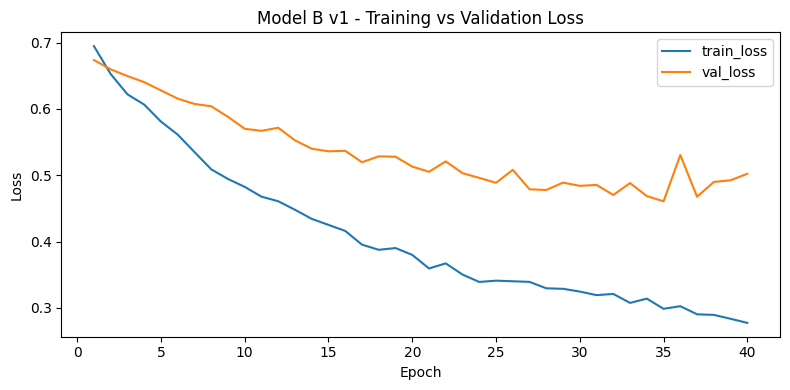

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
Test accuracy (percent correct up/down): 37.22%


In [25]:
LOOKBACK = 12
CUTOFF = pd.Timestamp("2021-09-01")
BATCH_SIZE = 32
EPOCHS = 40
SEED = 42
EARLY_STOPPING_PATIENCE = 8

tf.random.set_seed(SEED)
np.random.seed(SEED)

countries = ["Belgium","Bulgaria","Croatia","Czechia","Hungary","Ireland","Malta","Poland","Romania","Slovakia","Cyprus"]

df, VALUE_COL = clean_country_week_data(final_df, countries, use_per_capita=False)
train_df, test_df = split_by_time(df, CUTOFF)
train_scaled, test_scaled, feature_cols = scale_measures_and_target(train_df, test_df, VALUE_COL, include_target=False)

X_train, y_train = make_sequences_updown(train_scaled, LOOKBACK, feature_cols, VALUE_COL)
X_test, y_test = make_sequences_updown(test_scaled, LOOKBACK, feature_cols, VALUE_COL)

if X_train.shape[0] == 0 or X_test.shape[0] == 0:
    raise ValueError("No sequences created. Reduce LOOKBACK or ensure enough weeks per country.")

pos_rate, sample_weight = compute_balanced_sample_weight(y_train)
X_train_s, y_train_s, sample_weight_s = shuffle_in_unison(SEED, X_train, y_train, sample_weight)

model = build_direction_only_lstm(LOOKBACK, X_train.shape[2])
history = fit_direction_only(model, X_train_s, y_train_s, sample_weight_s, BATCH_SIZE, EPOCHS, EARLY_STOPPING_PATIENCE, verbose=0)
plot_loss_curve(history, "Model B v1 - Training vs Validation Loss")

p_test = model.predict(X_test, batch_size=BATCH_SIZE).reshape(-1)
y_pred = (p_test >= 0.5).astype(np.float32)

acc = float(np.mean(y_pred == y_test)) * 100.0
print(f"Test accuracy (percent correct up/down): {acc:.2f}%")


Duplicate rows: 0 Duplicate (Country,week) groups: 0
Duplicates after fix: 0
Epoch 1/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - dense_3_acc: 0.5749 - dense_3_auc: 0.6194 - dense_3_loss: 0.6806 - dense_4_loss: 0.1920 - dense_4_mae: 1.0570 - loss: 0.6903 - val_dense_3_acc: 0.5774 - val_dense_3_auc: 0.6346 - val_dense_3_loss: 0.6726 - val_dense_4_loss: 0.1775 - val_dense_4_mae: 0.9950 - val_loss: 0.6827
Epoch 2/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - dense_3_acc: 0.6826 - dense_3_auc: 0.7296 - dense_3_loss: 0.6435 - dense_4_loss: 0.1884 - dense_4_mae: 1.0389 - loss: 0.6528 - val_dense_3_acc: 0.6071 - val_dense_3_auc: 0.6388 - val_dense_3_loss: 0.6587 - val_dense_4_loss: 0.1745 - val_dense_4_mae: 0.9825 - val_loss: 0.6681
Epoch 3/40
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - dense_3_acc: 0.6871 - dense_3_auc: 0.7452 - dense_3_loss: 0.6101 - dense_4_loss: 0.1846 - dense_4_mae: 1.0194 - loss: 0.6190 - val_dense_3_acc: 0.6250 - val_dense_3_auc: 0.6422 - val_dense_3_loss: 0.6513 - val_de

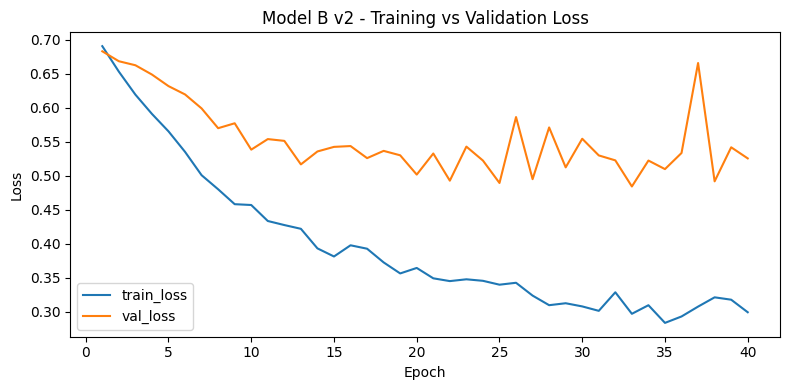

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
Train rows: 968 Test rows: 441
Train range: 2019-12-30 00:00:00 → 2021-08-30 00:00:00
Test  range: 2021-09-06 00:00:00 → 2022-06-13 00:00:00

=== Direction metrics (overall) ===
Pos rate (train): 0.5167464017868042
Accuracy (label-based): 0.46601941747572817
Accuracy (true log-change sign): 0.46601941747572817
AUC: 0.46935563207083125
Precision: 0.28125
Recall: 0.47368421052631576
F1: 0.35294117647058826

Confusion matrix:
 [[ 99 115]
 [ 50  45]]

Classification report:
               precision    recall  f1-score   support

         0.0     0.6644    0.4626    0.5455       214
         1.0     0.2812    0.4737    0.3529        95

    accuracy                         0.4660       309
   macro avg     0.4728    0.4682    0.4492       309
weighted avg     0.5466    0.4660    0.4863       309


=== Magnitude/counts metrics (overall) ===
Magnitude cap (99% train): 1.3387198448181152
Mean |mag| (true): 0.344086229801178
Mean |mag| (pred): 0.320901900

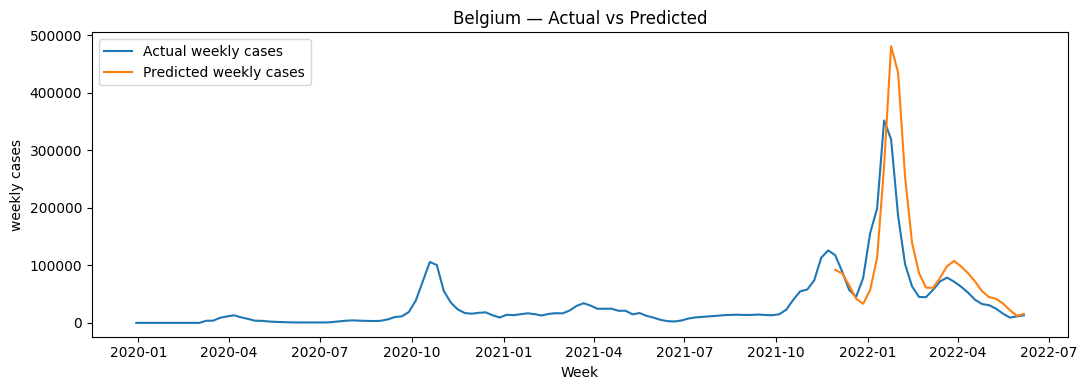

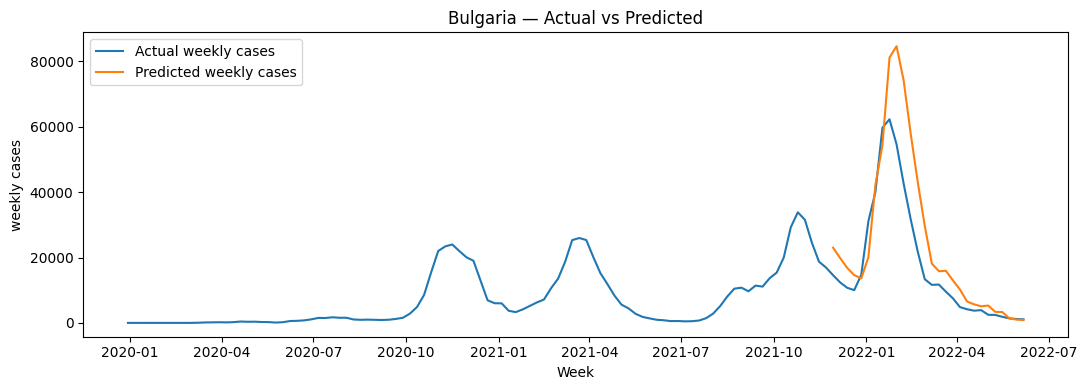

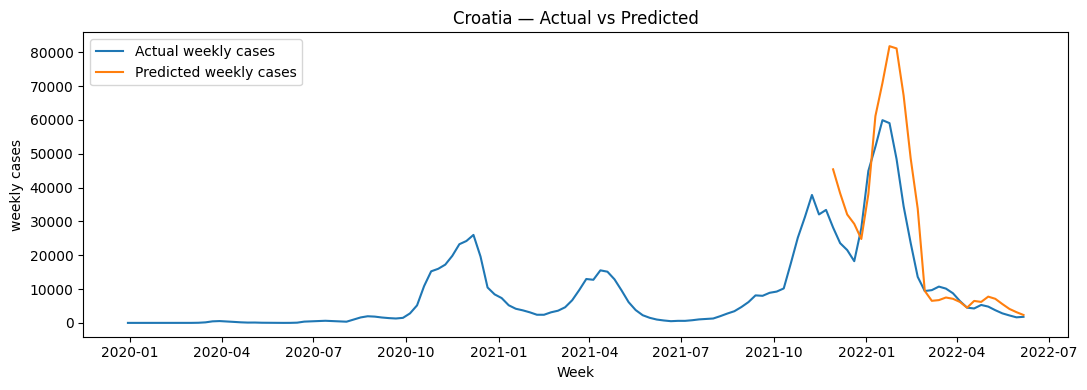

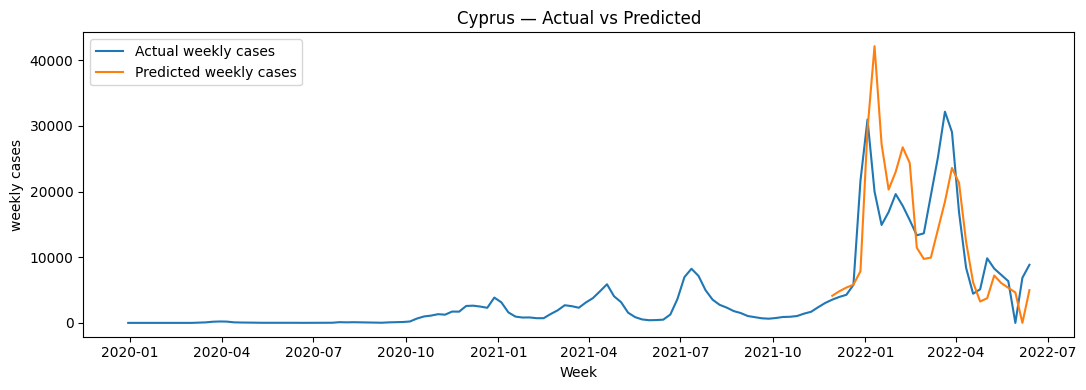

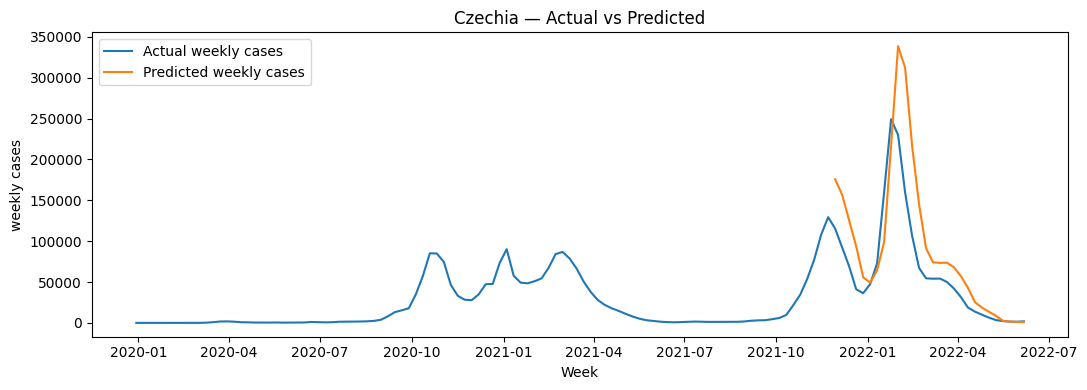

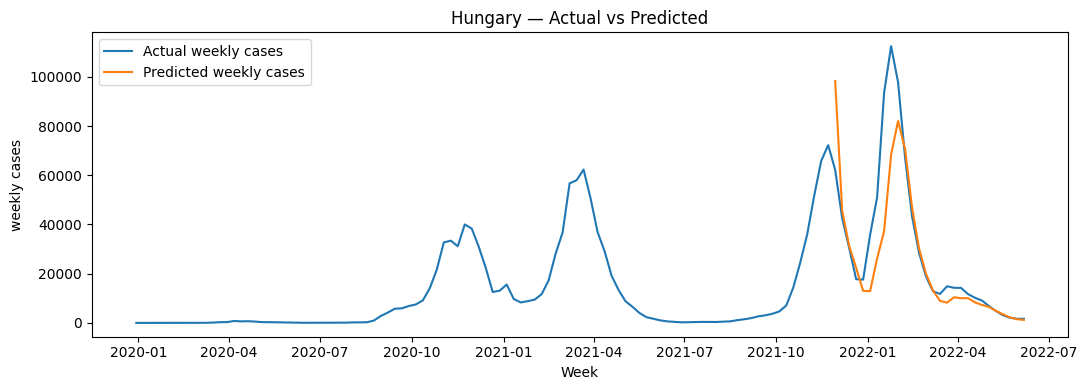

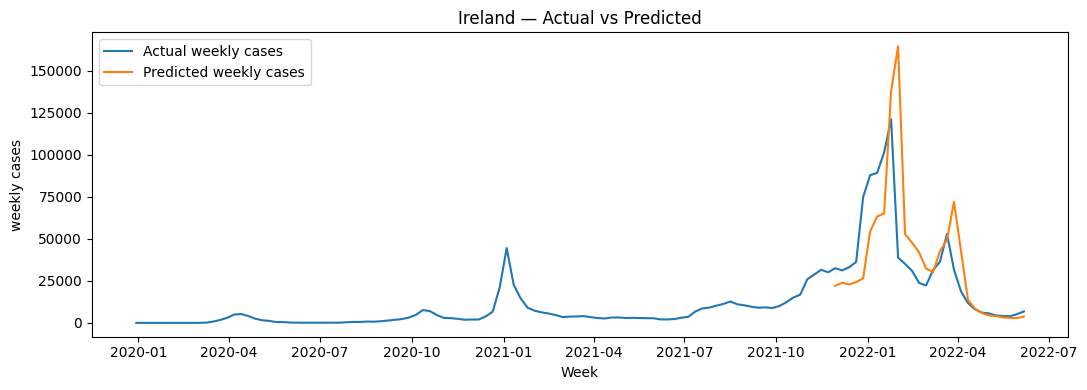

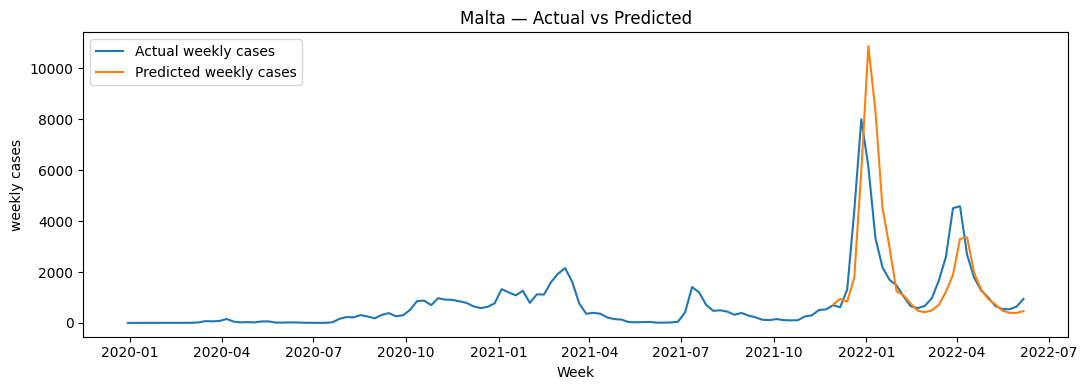

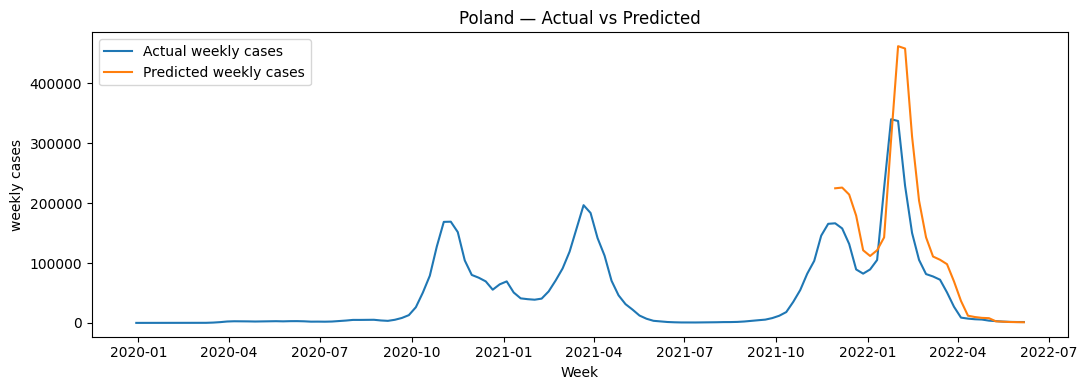

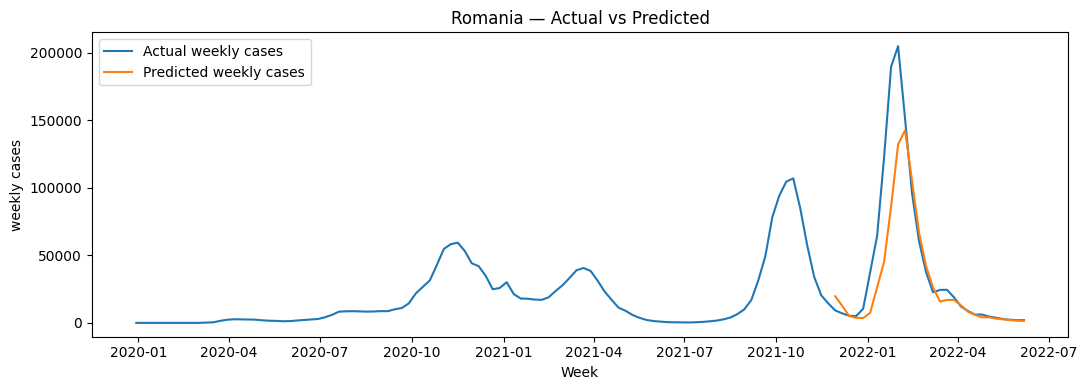

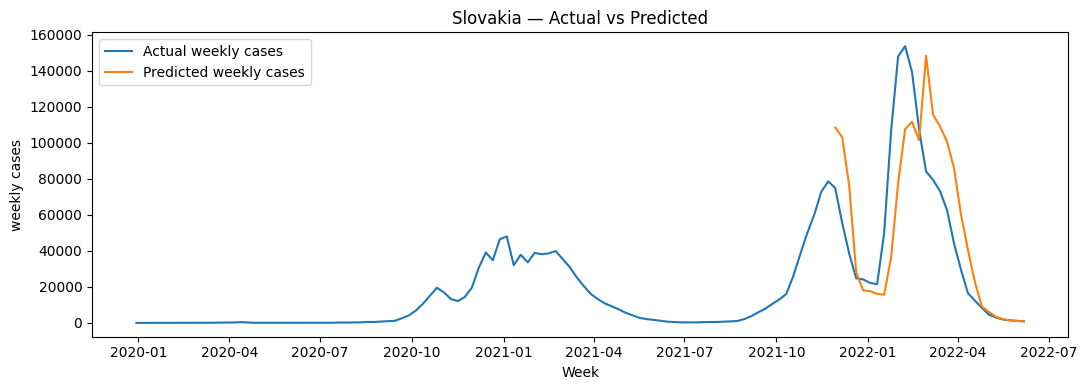

In [26]:
LOOKBACK = 12
CUTOFF = pd.Timestamp("2021-09-01")
BATCH_SIZE = 32
EPOCHS = 40
SEED = 42
EARLY_STOPPING_PATIENCE = 8

DELTA_HUBER = 0.2
LAMBDA_MAG = 0.05
THRESH_PCT = 0.0

tf.random.set_seed(SEED)
np.random.seed(SEED)

countries = ["Belgium","Bulgaria","Croatia","Czechia","Hungary","Ireland","Malta","Poland","Romania","Slovakia","Cyprus"]

df, VALUE_COL = clean_country_week_data(final_df, countries, use_per_capita=False)
train_df, test_df = split_by_time(df, CUTOFF)
train_scaled, test_scaled, feature_cols = scale_measures_and_target(train_df, test_df, VALUE_COL, include_target=True)

X_train, y_train_dir, y_train_mag, meta_train = make_sequences_twohead(train_scaled, LOOKBACK, feature_cols, VALUE_COL, THRESH_PCT, min_denom=1.0)
X_test, y_test_dir, y_test_mag, meta_test = make_sequences_twohead(test_scaled, LOOKBACK, feature_cols, VALUE_COL, THRESH_PCT, min_denom=1.0)

if X_train.shape[0] == 0 or X_test.shape[0] == 0:
    raise ValueError("No sequences created. Reduce LOOKBACK or extend date range.")

mag_mean = float(y_train_mag.mean())
mag_std = float(y_train_mag.std() + 1e-9)
y_train_mag_s = (y_train_mag - mag_mean) / mag_std

pos_rate, sample_weight_dir = compute_balanced_sample_weight(y_train_dir)
X_train_s, y_train_dir_s, y_train_mag_s_s, sample_weight_dir_s = shuffle_in_unison(
    SEED, X_train, y_train_dir, y_train_mag_s, sample_weight_dir
)

model = build_two_head_lstm(LOOKBACK, X_train.shape[2], DELTA_HUBER, LAMBDA_MAG)
history = fit_two_head(model, X_train_s, y_train_dir_s, y_train_mag_s_s, sample_weight_dir_s, BATCH_SIZE, EPOCHS, EARLY_STOPPING_PATIENCE, verbose=1)
plot_loss_curve(history, "Model B v2 - Training vs Validation Loss")

metrics, pred_counts = evaluate_two_head(model, X_test, y_test_dir, y_test_mag, meta_test, y_train_mag, mag_mean, mag_std, BATCH_SIZE)

print("Train rows:", len(train_df), "Test rows:", len(test_df))
print("Train range:", train_df["week"].min(), "→", train_df["week"].max())
print("Test  range:", test_df["week"].min(), "→", test_df["week"].max())

print_two_head_metrics(pos_rate, metrics, y_test_dir, value_label="counts")

meta_plot = pd.DataFrame(meta_test, columns=["Country","week","prev","true","true_r"])
meta_plot["week"] = pd.to_datetime(meta_plot["week"])
meta_plot["pred"] = pred_counts

actual_plot = final_df[["Country","week","weekly_count"]].copy()
actual_plot["week"] = pd.to_datetime(actual_plot["week"])
actual_plot["weekly_count"] = pd.to_numeric(actual_plot["weekly_count"], errors="coerce")
actual_plot["Country"] = actual_plot["Country"].astype(str)
actual_plot = actual_plot[actual_plot["Country"].isin(countries)].copy()
actual_plot = actual_plot.dropna(subset=["week","weekly_count","Country"]).copy()
actual_plot = (
    actual_plot.groupby(["Country","week"], as_index=False)["weekly_count"]
    .sum()
    .sort_values(["Country","week"])
    .reset_index(drop=True)
)

plot_country_predictions(actual_plot, meta_plot[["Country","week","pred"]], "weekly_count", "weekly cases")


### Model B, v3: LSTM Classifier - Per-Capita Scaling, Shorter Lookback
Case counts are normalized per 100k population (`PER_CAPITA_SCALE`) so country size
doesn't dominate the signal, and lookback is shortened to 8 weeks to test sensitivity
to window length.

Duplicate rows: 0 Duplicate (Country,week) groups: 0
Duplicates after fix: 0
Epoch 1/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - dense_6_acc: 0.5753 - dense_6_auc: 0.6241 - dense_6_loss: 0.6817 - dense_7_loss: 0.1740 - dense_7_mae: 0.9664 - loss: 0.6904 - val_dense_6_acc: 0.6307 - val_dense_6_auc: 0.6439 - val_dense_6_loss: 0.6647 - val_dense_7_loss: 0.1846 - val_dense_7_mae: 1.0396 - val_loss: 0.6727
Epoch 2/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - dense_6_acc: 0.6705 - dense_6_auc: 0.7167 - dense_6_loss: 0.6369 - dense_7_loss: 0.1673 - dense_7_mae: 0.9334 - loss: 0.6453 - val_dense_6_acc: 0.6648 - val_dense_6_auc: 0.6745 - val_dense_6_loss: 0.6389 - val_dense_7_loss: 0.1781 - val_dense_7_mae: 1.0072 - val_loss: 0.6482
Epoch 3/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - dense_6_acc: 0.6903 - dense_6_auc: 0.7445 - dense_6_loss: 0.5921 - dense_7_loss: 0.1613 - dense_7_mae: 0.9027 - loss: 0.6001 - val_dense_6_acc: 0.6761 - val_dense_6_auc: 0.6766 - val_dense_6_loss: 0.6473 - val_de

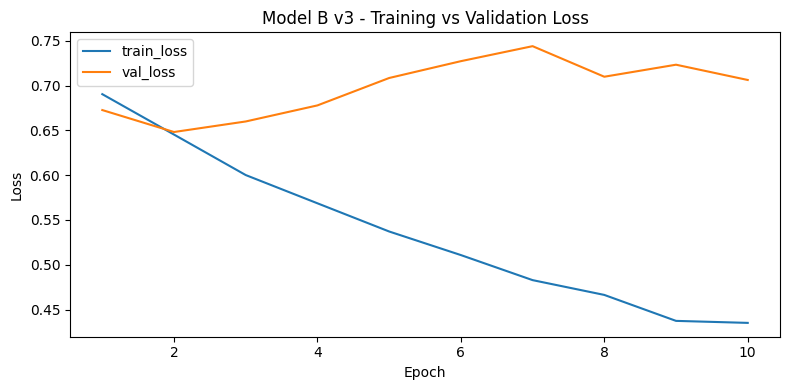

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
Train rows: 968 Test rows: 441
Train range: 2019-12-30 00:00:00 → 2021-08-30 00:00:00
Test  range: 2021-09-06 00:00:00 → 2022-06-13 00:00:00

=== Direction metrics (overall) ===
Pos rate (train): 0.5306817889213562
Accuracy (label-based): 0.41359773371104813
Accuracy (true log-change sign): 0.41359773371104813
AUC: 0.4702727021040975
Precision: 0.35661764705882354
Recall: 0.751937984496124
F1: 0.4837905236907731

Confusion matrix:
 [[ 49 175]
 [ 32  97]]

Classification report:
               precision    recall  f1-score   support

         0.0     0.6049    0.2188    0.3213       224
         1.0     0.3566    0.7519    0.4838       129

    accuracy                         0.4136       353
   macro avg     0.4808    0.4853    0.4026       353
weighted avg     0.5142    0.4136    0.3807       353


=== Magnitude/rate metrics (overall) ===
Magnitude cap (99% train): 1.2656522989273071
Mean |mag| (true): 0.3189433515071869
Mean |mag| (pred): 0.44

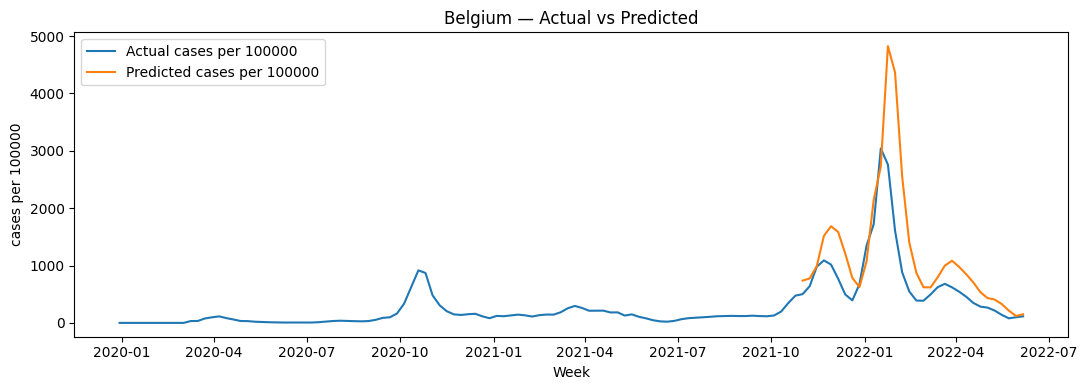

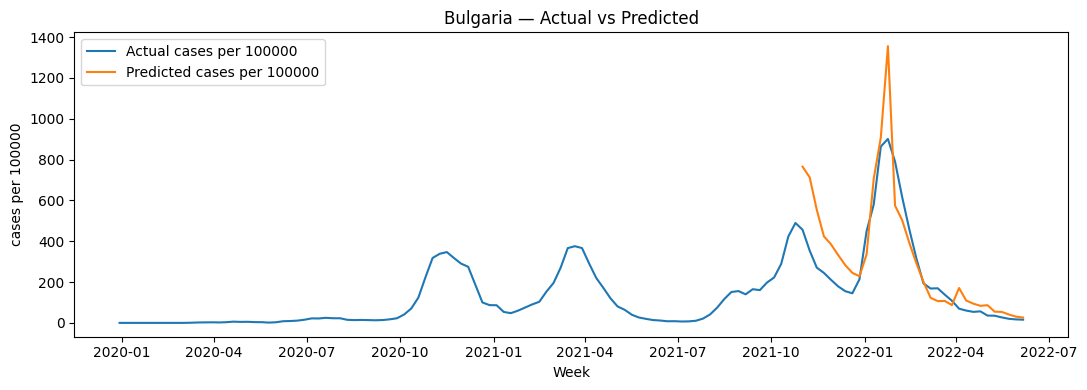

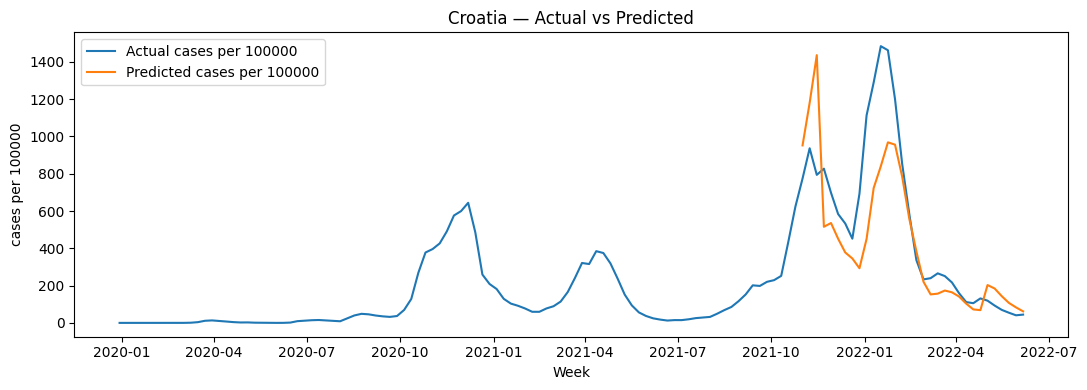

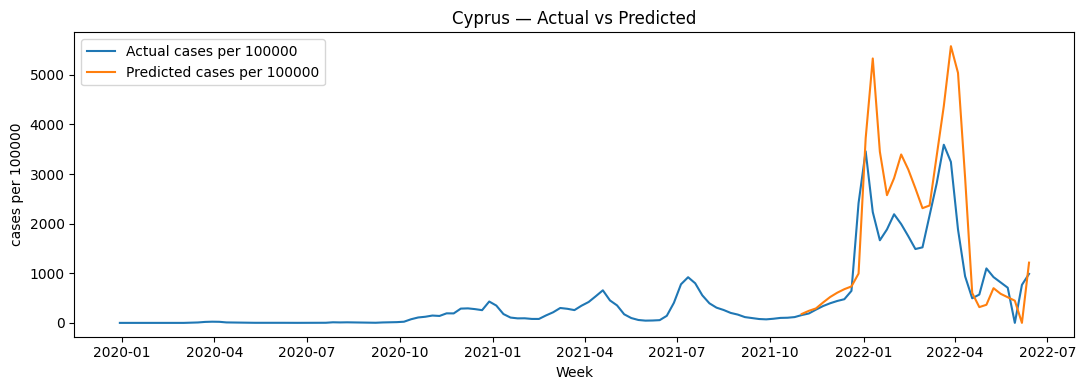

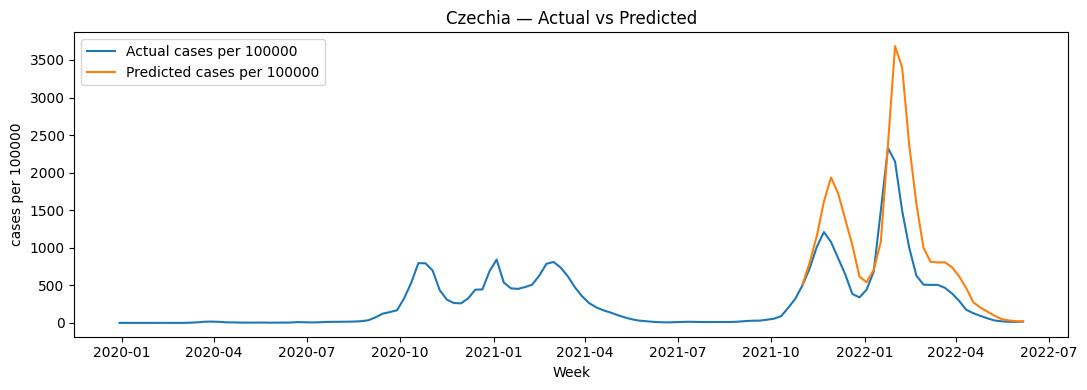

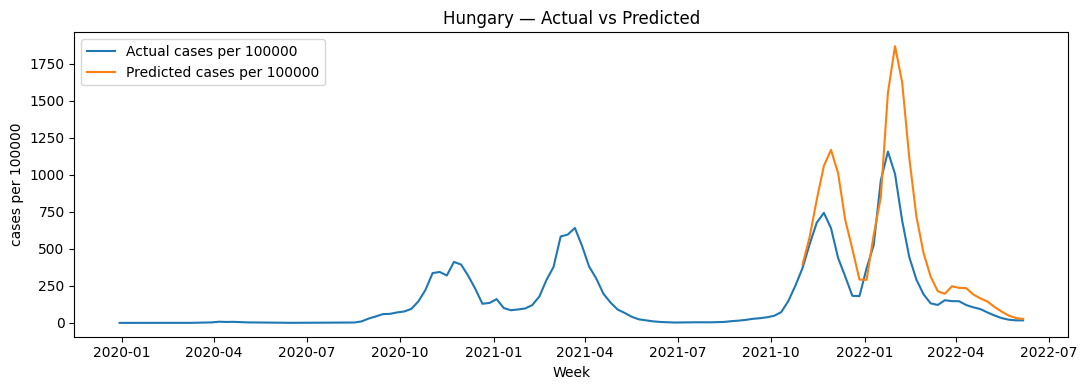

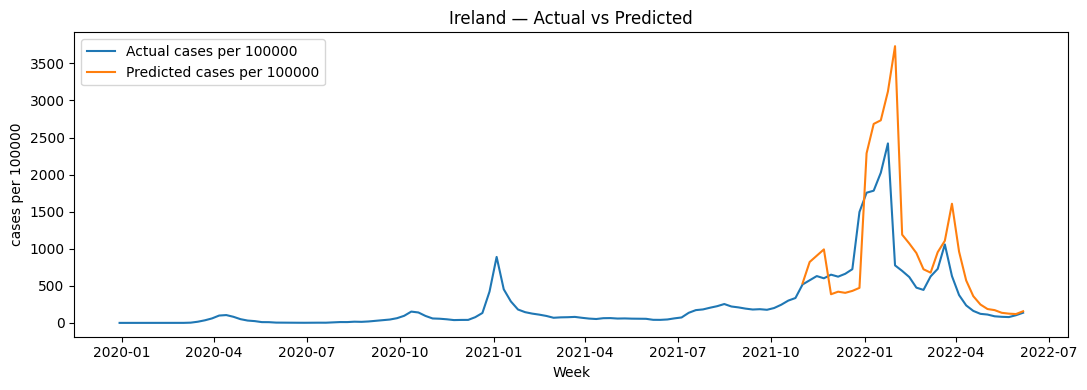

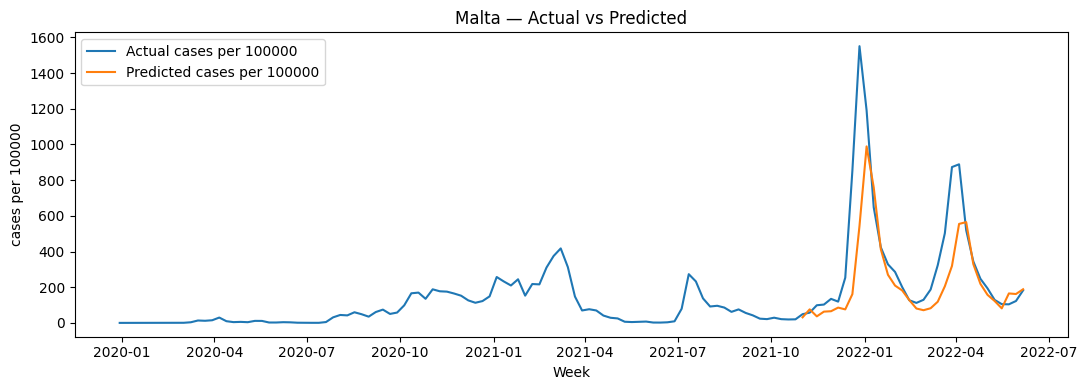

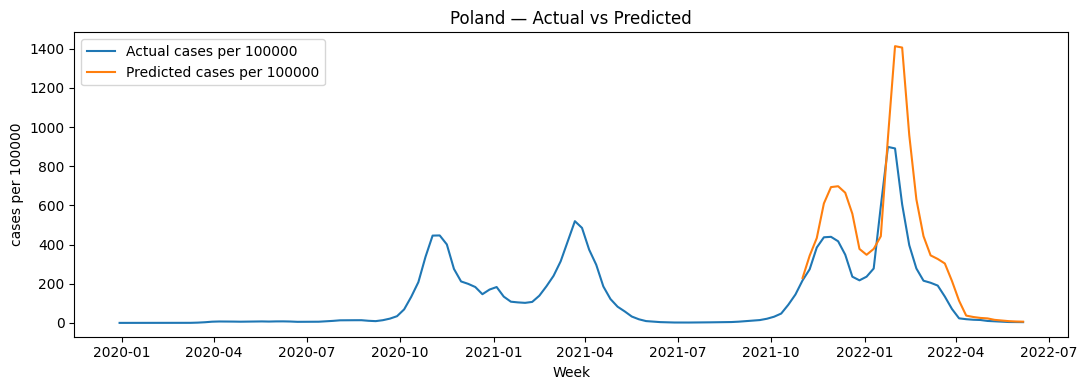

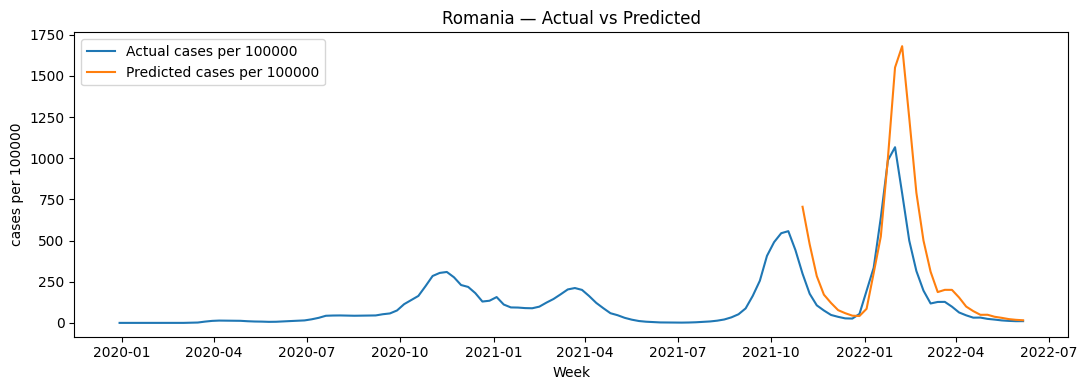

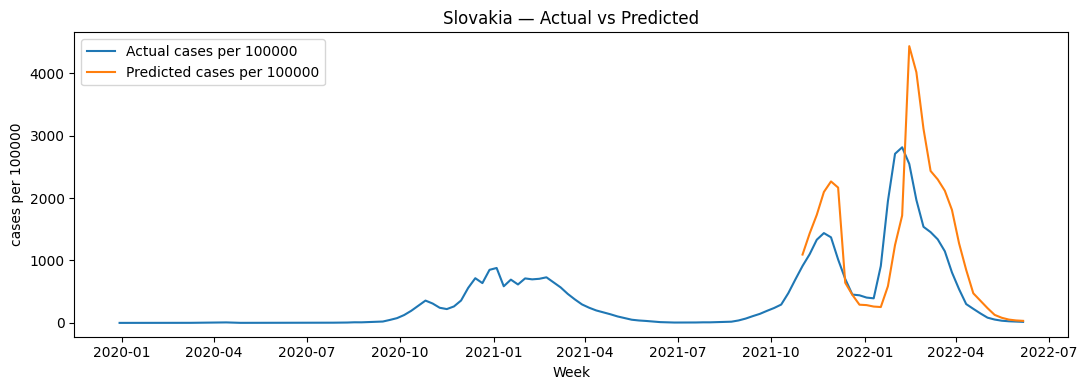

In [28]:
LOOKBACK = 8
CUTOFF = pd.Timestamp("2021-09-01")
BATCH_SIZE = 32
EPOCHS = 40
SEED = 42
EARLY_STOPPING_PATIENCE = 8

DELTA_HUBER = 0.2
LAMBDA_MAG = 0.05
THRESH_PCT = 0.0
PER_CAPITA_SCALE = 100000.0

tf.random.set_seed(SEED)
np.random.seed(SEED)

countries = ["Belgium","Bulgaria","Croatia","Czechia","Hungary","Ireland","Malta","Poland","Romania","Slovakia","Cyprus"]

df, VALUE_COL = clean_country_week_data(final_df, countries, use_per_capita=True, per_capita_scale=PER_CAPITA_SCALE)
train_df, test_df = split_by_time(df, CUTOFF)
train_scaled, test_scaled, feature_cols = scale_measures_and_target(train_df, test_df, VALUE_COL, include_target=True)

X_train, y_train_dir, y_train_mag, meta_train = make_sequences_twohead(train_scaled, LOOKBACK, feature_cols, VALUE_COL, THRESH_PCT, min_denom=1e-6)
X_test, y_test_dir, y_test_mag, meta_test = make_sequences_twohead(test_scaled, LOOKBACK, feature_cols, VALUE_COL, THRESH_PCT, min_denom=1e-6)

if X_train.shape[0] == 0 or X_test.shape[0] == 0:
    raise ValueError("No sequences created. Reduce LOOKBACK or extend date range.")

mag_mean = float(y_train_mag.mean())
mag_std = float(y_train_mag.std() + 1e-9)
y_train_mag_s = (y_train_mag - mag_mean) / mag_std

pos_rate, sample_weight_dir = compute_balanced_sample_weight(y_train_dir)
X_train_s, y_train_dir_s, y_train_mag_s_s, sample_weight_dir_s = shuffle_in_unison(
    SEED, X_train, y_train_dir, y_train_mag_s, sample_weight_dir
)

model = build_two_head_lstm(LOOKBACK, X_train.shape[2], DELTA_HUBER, LAMBDA_MAG)
history = fit_two_head(model, X_train_s, y_train_dir_s, y_train_mag_s_s, sample_weight_dir_s, BATCH_SIZE, EPOCHS, EARLY_STOPPING_PATIENCE, verbose=1)
plot_loss_curve(history, "Model B v3 - Training vs Validation Loss")

metrics, pred_rates = evaluate_two_head(model, X_test, y_test_dir, y_test_mag, meta_test, y_train_mag, mag_mean, mag_std, BATCH_SIZE)

print("Train rows:", len(train_df), "Test rows:", len(test_df))
print("Train range:", train_df["week"].min(), "→", train_df["week"].max())
print("Test  range:", test_df["week"].min(), "→", test_df["week"].max())

print_two_head_metrics(pos_rate, metrics, y_test_dir, value_label="rate")

meta_plot = pd.DataFrame(meta_test, columns=["Country","week","prev_rate","true_rate","true_r"])
meta_plot["week"] = pd.to_datetime(meta_plot["week"])
meta_plot["pred"] = pred_rates

actual_plot = final_df[["Country","week","weekly_count","population"]].copy()
actual_plot["week"] = pd.to_datetime(actual_plot["week"])
actual_plot["weekly_count"] = pd.to_numeric(actual_plot["weekly_count"], errors="coerce")
actual_plot["population"] = pd.to_numeric(actual_plot["population"], errors="coerce")
actual_plot["Country"] = actual_plot["Country"].astype(str)
actual_plot = actual_plot[actual_plot["Country"].isin(countries)].copy()
actual_plot = actual_plot.dropna(subset=["week","weekly_count","Country","population"]).copy()
actual_plot = (
    actual_plot.groupby(["Country","week"], as_index=False)
    .agg({"weekly_count":"sum", "population":"first"})
    .sort_values(["Country","week"])
    .reset_index(drop=True)
)
actual_plot["weekly_per_100k"] = actual_plot["weekly_count"].astype(float) / actual_plot["population"].astype(float) * PER_CAPITA_SCALE
actual_plot["weekly_per_100k"] = actual_plot["weekly_per_100k"].replace([np.inf, -np.inf], np.nan)

plot_country_predictions(
    actual_plot[["Country","week","weekly_per_100k"]],
    meta_plot[["Country","week","pred"]],
    "weekly_per_100k",
    f"cases per {int(PER_CAPITA_SCALE)}",
)


### Model B, v4: LSTM Classifier - Final Configuration


**Tuned in this version:**
- `LOOKBACK=12` weeks, chosen after sweeping {3, 6, 8, 12, 16} - best tradeoff of
  direction accuracy/AUC vs. magnitude error.
- `BATCH_SIZE=32`, sized for the actual training-sequence count (a few hundred to
  ~1,000 sequences) 
- Early stopping `patience=10` with `min_delta=1e-4` (up from patience=8), since the
  smaller batch size means noisier per-epoch validation loss - a short patience risked
  stopping on a single noisy epoch rather than a genuine plateau.


Duplicate rows: 0 Duplicate (Country,week) groups: 0
Duplicates after fix: 0
Train countries: ['Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Hungary', 'Ireland', 'Poland', 'Romania']
Test  countries: ['Slovakia', 'Belgium', 'Malta']
Train sequences: 929 | Test sequences: 348 | Lookback: 12 | Batch size: 32
Epoch 1/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - dense_12_acc: 0.5316 - dense_12_auc: 0.5671 - dense_12_loss: 0.6881 - dense_13_loss: 0.1479 - dense_13_mae: 0.8376 - loss: 0.6944 - val_dense_12_acc: 0.6183 - val_dense_12_auc: 0.7339 - val_dense_12_loss: 0.6650 - val_dense_13_loss: 0.1271 - val_dense_13_mae: 0.7326 - val_loss: 0.6714
Epoch 2/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - dense_12_acc: 0.6353 - dense_12_auc: 0.7070 - dense_12_loss: 0.6623 - dense_13_loss: 0.1403 - dense_13_mae: 0.7965 - loss: 0.6674 - val_dense_12_acc: 0.6989 - val_dense_12_auc: 0.7669 - val_dense_12_loss: 0.6313 - val_dense_13_loss: 0.1178 - val_dense_13_mae: 0.6848 - val_loss: 0.6372
Epoch 3/40
24/2

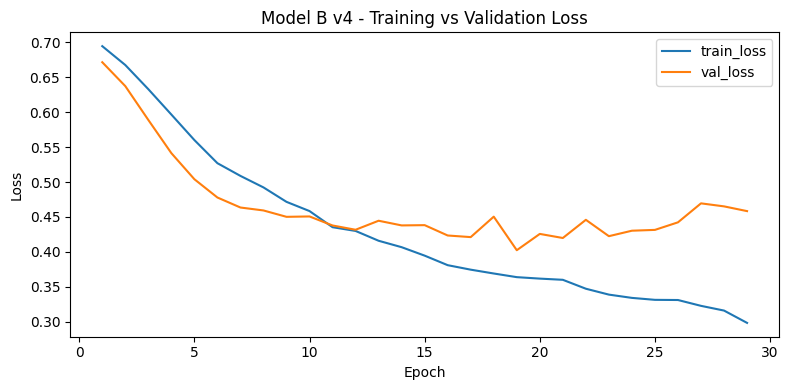

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
Train countries: ['Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Hungary', 'Ireland', 'Poland', 'Romania']
Test  countries: ['Slovakia', 'Belgium', 'Malta']
Train rows: 1025 Test rows: 384

=== Direction metrics (overall) ===
Pos rate (train): 0.4994617998600006
Accuracy (label-based): 0.6695402298850575
Accuracy (true log-change sign): 0.6695402298850575
AUC: 0.7397391764861644
Precision: 0.6363636363636364
Recall: 0.7168674698795181
F1: 0.6742209631728046

Confusion matrix:
 [[114  68]
 [ 47 119]]

Classification report:
               precision    recall  f1-score   support

         0.0     0.7081    0.6264    0.6647       182
         1.0     0.6364    0.7169    0.6742       166

    accuracy                         0.6695       348
   macro avg     0.6722    0.6716    0.6695       348
weighted avg     0.6739    0.6695    0.6693       348


=== Magnitude/rate metrics (overall) ===
Magnitude cap (99% train): 1.101422667503357
Mean |mag| (true):

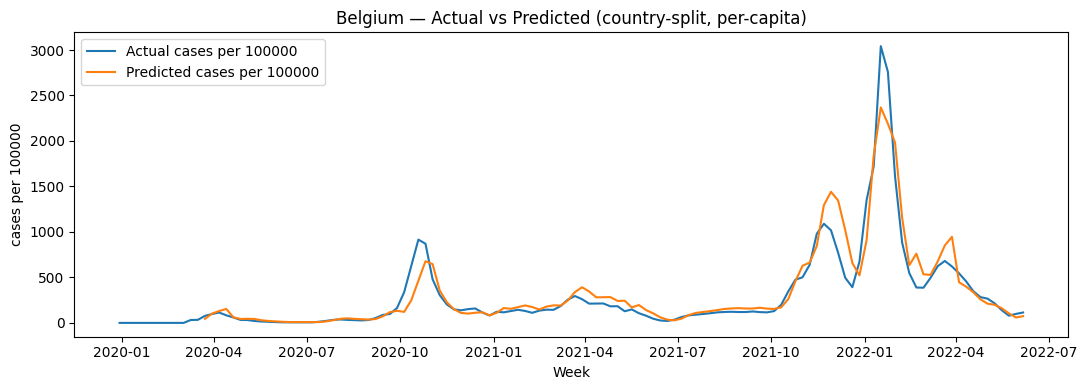

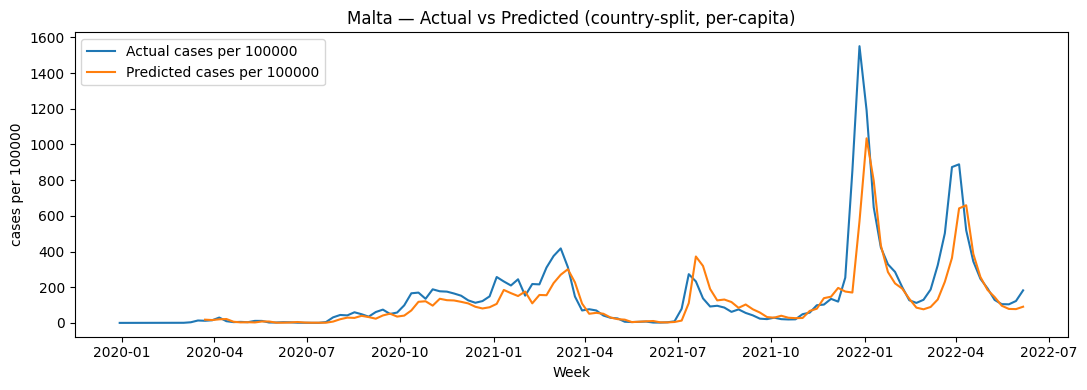

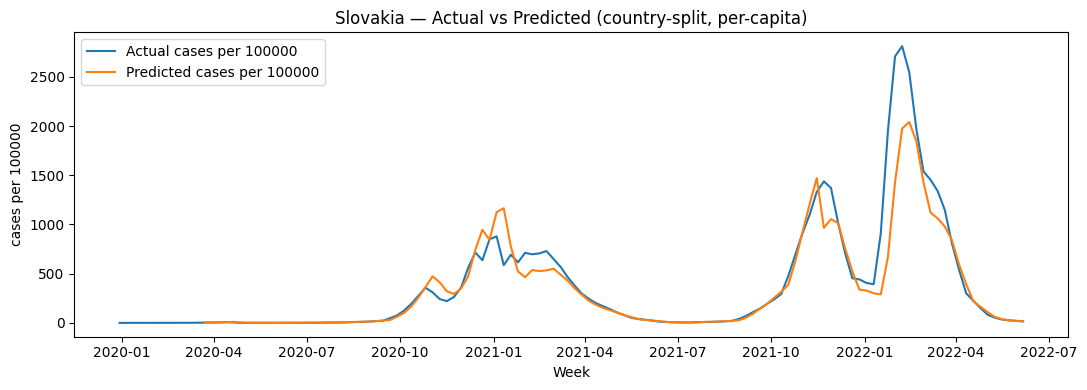

In [30]:
# LOOKBACK: a sweep across {3, 6, 8, 12, 16} weeks showed 12 gave the best
# combination of direction accuracy/AUC and magnitude error.
LOOKBACK = 12

# BATCH_SIZE: sized to the actual training-sequence count (a few hundred to
# ~1,000 sequences after windowing) rather than the original 512, which gave
# only 1-2 gradient updates per epoch - closer to full-batch gradient descent
# than mini-batch training.
BATCH_SIZE = 32

EPOCHS = 40
SEED = 42

DELTA_HUBER = 0.2
LAMBDA_MAG = 0.05
THRESH_PCT = 0.0

PER_CAPITA_SCALE = 100000.0
TEST_FRAC_COUNTRIES = 0.25


EARLY_STOPPING_PATIENCE = 10
EARLY_STOPPING_MIN_DELTA = 1e-4

tf.random.set_seed(SEED)
np.random.seed(SEED)

countries = ["Belgium","Bulgaria","Croatia","Czechia","Hungary","Ireland","Malta","Poland","Romania","Slovakia","Cyprus"]

df, VALUE_COL = clean_country_week_data(final_df, countries, use_per_capita=True, per_capita_scale=PER_CAPITA_SCALE)
train_df, test_df, train_countries, test_countries = split_by_country(df, SEED, TEST_FRAC_COUNTRIES)
train_scaled, test_scaled, feature_cols = scale_measures_and_target(train_df, test_df, VALUE_COL, include_target=True)

X_train, y_train_dir, y_train_mag, meta_train = make_sequences_twohead(train_scaled, LOOKBACK, feature_cols, VALUE_COL, THRESH_PCT, min_denom=1e-6)
X_test, y_test_dir, y_test_mag, meta_test = make_sequences_twohead(test_scaled, LOOKBACK, feature_cols, VALUE_COL, THRESH_PCT, min_denom=1e-6)

if X_train.shape[0] == 0 or X_test.shape[0] == 0:
    raise ValueError("No sequences created. Reduce LOOKBACK or check data length per country.")
print(f"Train sequences: {X_train.shape[0]} | Test sequences: {X_test.shape[0]} | Lookback: {LOOKBACK} | Batch size: {BATCH_SIZE}")

mag_mean = float(y_train_mag.mean())
mag_std = float(y_train_mag.std() + 1e-9)
y_train_mag_s = (y_train_mag - mag_mean) / mag_std

pos_rate, sample_weight_dir = compute_balanced_sample_weight(y_train_dir)
X_train_s, y_train_dir_s, y_train_mag_s_s, sample_weight_dir_s = shuffle_in_unison(
    SEED, X_train, y_train_dir, y_train_mag_s, sample_weight_dir
)

model = build_two_head_lstm(LOOKBACK, X_train.shape[2], DELTA_HUBER, LAMBDA_MAG)
history = fit_two_head(
    model, X_train_s, y_train_dir_s, y_train_mag_s_s, sample_weight_dir_s,
    BATCH_SIZE, EPOCHS, EARLY_STOPPING_PATIENCE, min_delta=EARLY_STOPPING_MIN_DELTA, verbose=1
)
plot_loss_curve(history, "Model B v4 - Training vs Validation Loss")

metrics, pred_rates = evaluate_two_head(model, X_test, y_test_dir, y_test_mag, meta_test, y_train_mag, mag_mean, mag_std, BATCH_SIZE)

print("Train countries:", list(train_countries))
print("Test  countries:", list(test_countries))
print("Train rows:", len(train_df), "Test rows:", len(test_df))

print_two_head_metrics(pos_rate, metrics, y_test_dir, value_label="rate")

meta_plot = pd.DataFrame(meta_test, columns=["Country","week","prev_rate","true_rate","true_r"])
meta_plot["week"] = pd.to_datetime(meta_plot["week"])
meta_plot["pred"] = pred_rates

actual_plot = df[df["Country"].isin(test_countries)][["Country","week","weekly_per_100k"]].copy()
actual_plot["week"] = pd.to_datetime(actual_plot["week"])
actual_plot = actual_plot.sort_values(["Country","week"]).reset_index(drop=True)

plot_country_predictions(
    actual_plot,
    meta_plot[["Country","week","pred"]],
    "weekly_per_100k",
    f"cases per {int(PER_CAPITA_SCALE)}",
    title_suffix="(country-split, per-capita)",
)


Duplicate rows: 0 Duplicate (Country,week) groups: 0
Duplicates after fix: 0
Train sequences: 495 | Test sequences: 650 | Lookback: 12 | Batch size: 32
Epoch 1/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - dense_21_acc: 0.5000 - dense_21_auc: 0.5105 - dense_21_loss: 0.6959 - dense_22_loss: 0.1920 - dense_22_mae: 1.0505 - loss: 0.7044 - val_dense_21_acc: 0.5960 - val_dense_21_auc: 0.5762 - val_dense_21_loss: 0.6674 - val_dense_22_loss: 0.1967 - val_dense_22_mae: 0.9972 - val_loss: 0.6947
Epoch 2/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - dense_21_acc: 0.6515 - dense_21_auc: 0.6913 - dense_21_loss: 0.6684 - dense_22_loss: 0.1891 - dense_22_mae: 1.0350 - loss: 0.6764 - val_dense_21_acc: 0.5859 - val_dense_21_auc: 0.5913 - val_dense_21_loss: 0.6564 - val_dense_22_loss: 0.1940 - val_dense_22_mae: 0.9850 - val_loss: 0.6883
Epoch 3/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - dense_21_acc: 0.6995 - dense_21_auc: 0.7554 - dense_21_loss: 0.6403 - dense_22_loss: 0.1867 - dense_22_mae: 1.0223 - 

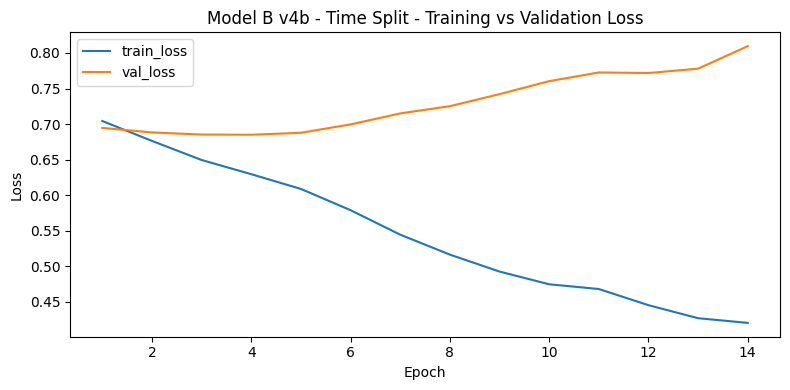

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Train rows: 627 Test rows: 782
Train range: 2019-12-30 00:00:00 → 2021-01-25 00:00:00
Test  range: 2021-02-01 00:00:00 → 2022-06-13 00:00:00

=== Direction metrics (overall) ===
Pos rate (train): 0.5494949221611023
Accuracy (label-based): 0.56
Accuracy (true log-change sign): 0.56
AUC: 0.6419444444444444
Precision: 0.5050505050505051
Recall: 0.6896551724137931
F1: 0.5830903790087464

Confusion matrix:
 [[164 196]
 [ 90 200]]

Classification report:
               precision    recall  f1-score   support

         0.0     0.6457    0.4556    0.5342       360
         1.0     0.5051    0.6897    0.5831       290

    accuracy                         0.5600       650
   macro avg     0.5754    0.5726    0.5586       650
weighted avg     0.5829    0.5600    0.5560       650


=== Magnitude/rate metrics (overall) ===
Magnitude cap (99% train): 1.1544172763824463
Mean |mag| (true): 0.3056067228317261
Mean |mag| (pred): 0.43308767676353455
MAE rate: 188.

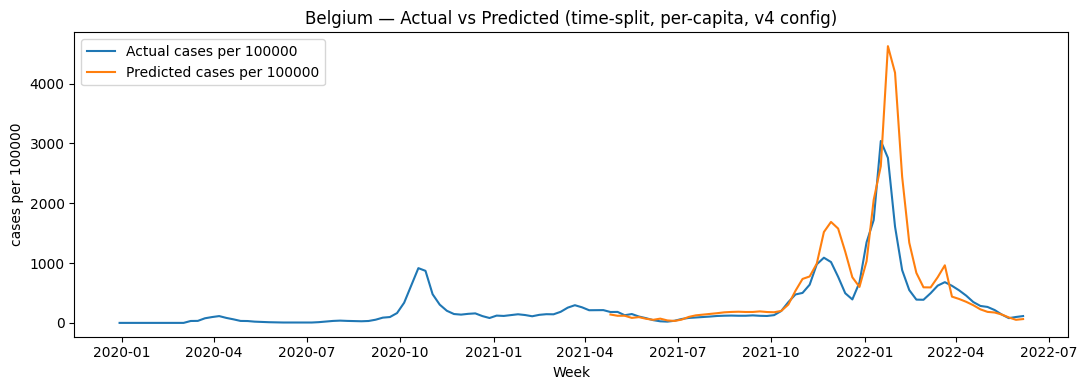

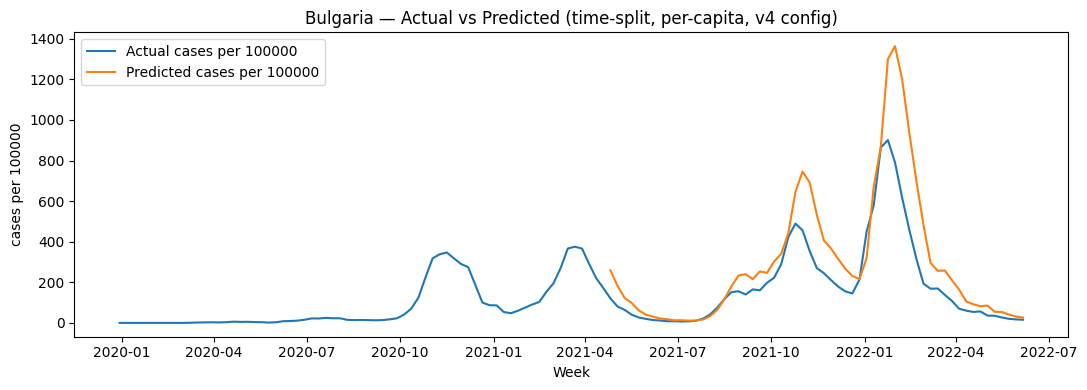

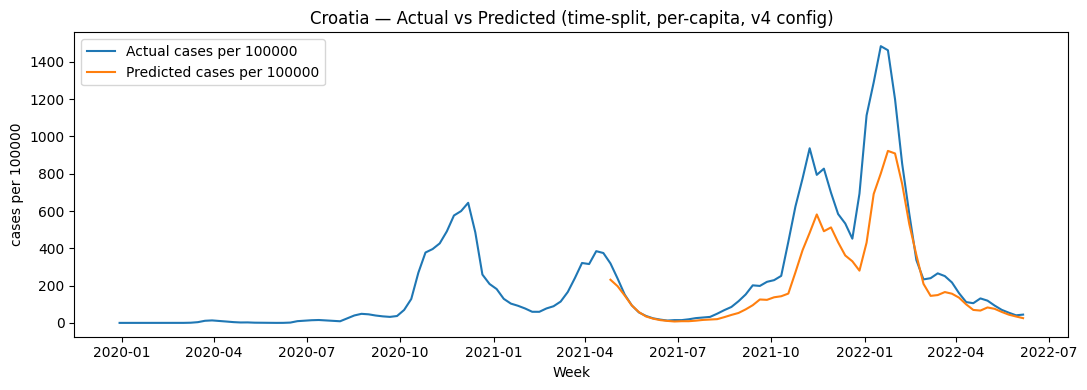

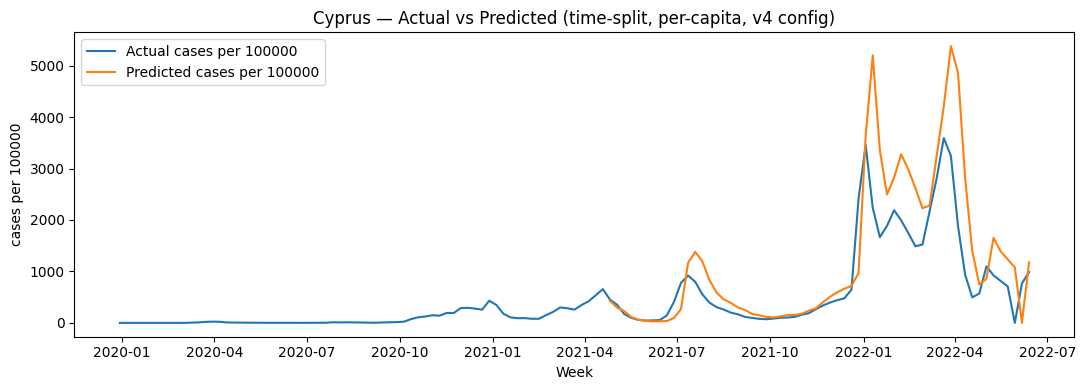

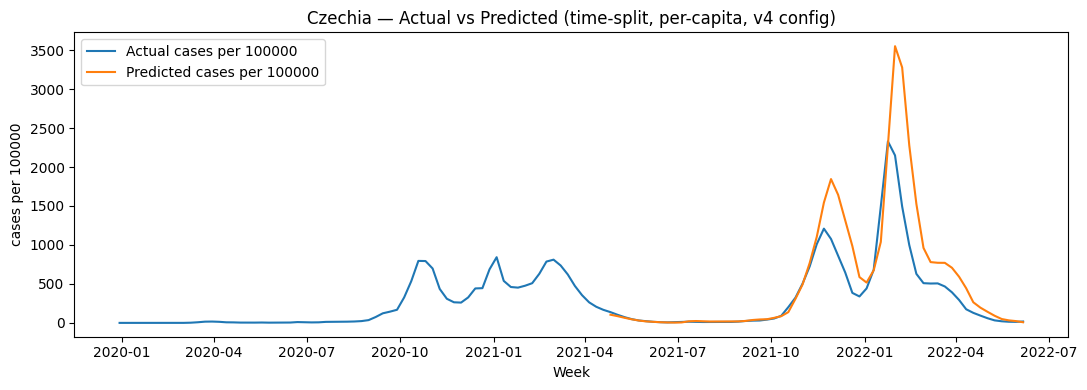

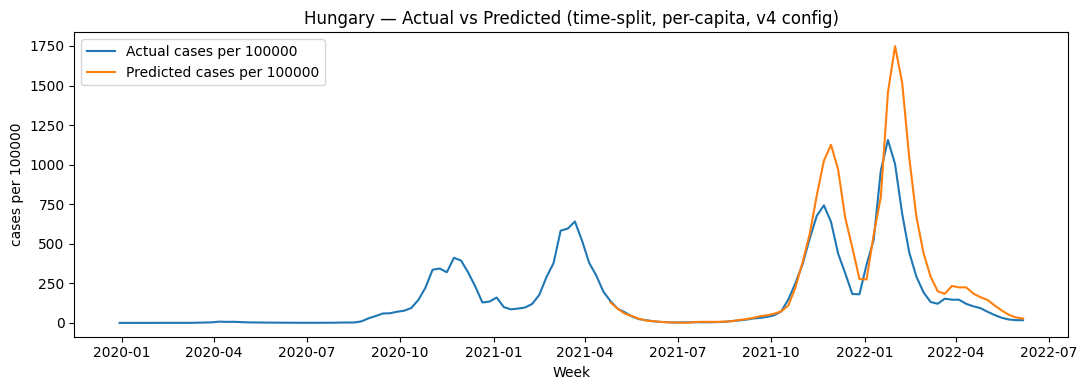

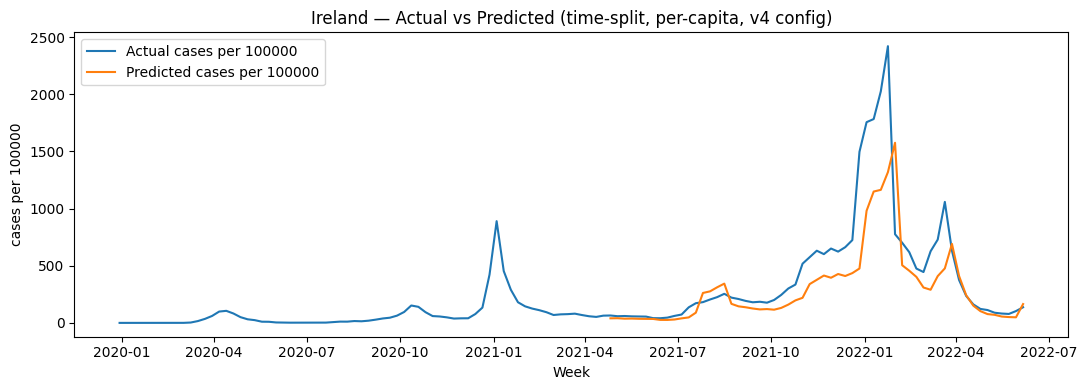

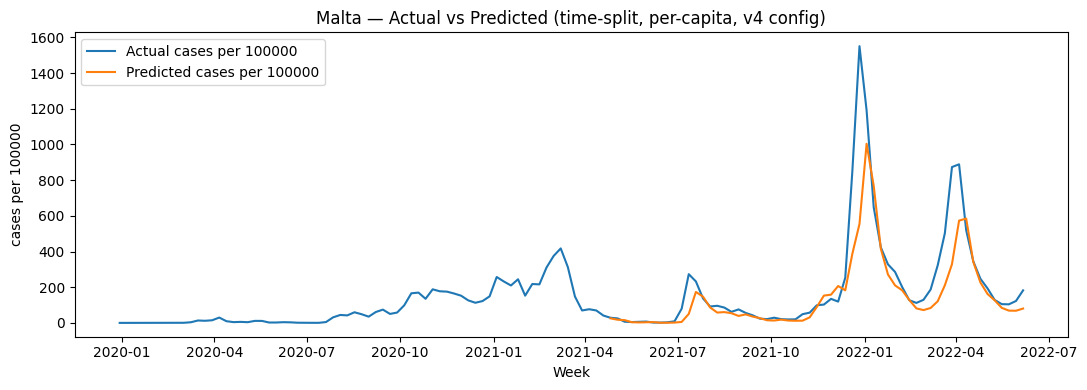

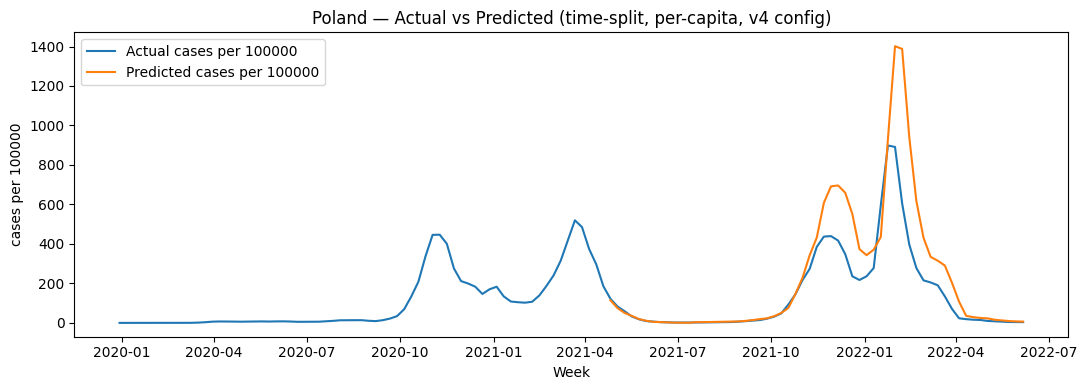

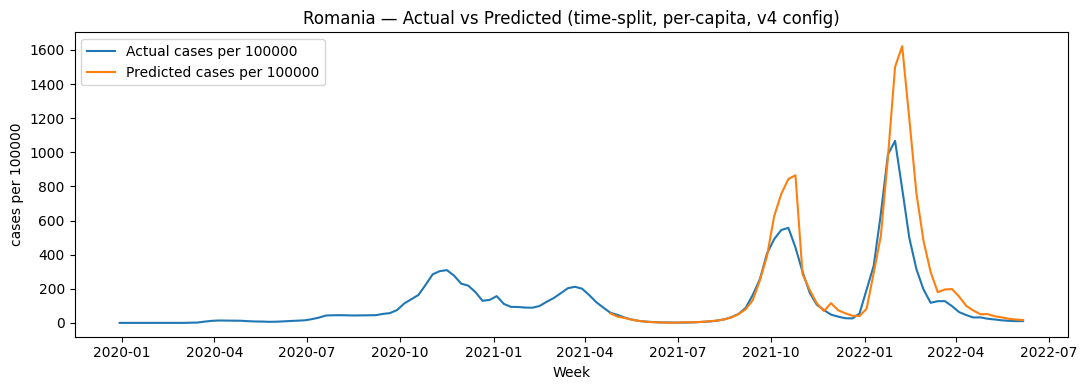

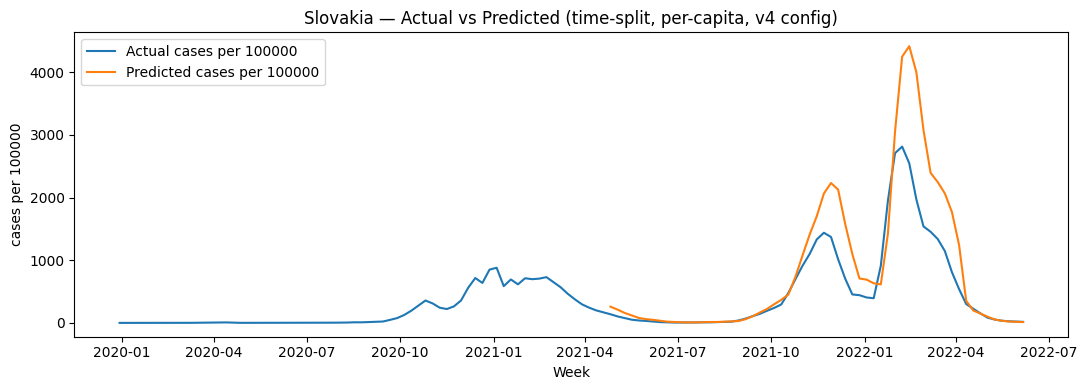

In [33]:
# Model B v4b: same config as v4, but with a TIME-based split instead of a
# country-based one - isolates whether v4's strong performance comes from
# the split strategy itself, or from the other changes (per-capita scaling,
# patience/min_delta) it also introduced relative to v1-v3.

LOOKBACK = 12
CUTOFF = pd.Timestamp("2021-02-01")
BATCH_SIZE = 32
EPOCHS = 40
SEED = 42

DELTA_HUBER = 0.2
LAMBDA_MAG = 0.05
THRESH_PCT = 0.0
PER_CAPITA_SCALE = 100000.0

EARLY_STOPPING_PATIENCE = 10
EARLY_STOPPING_MIN_DELTA = 1e-4

tf.random.set_seed(SEED)
np.random.seed(SEED)

countries = ["Belgium","Bulgaria","Croatia","Czechia","Hungary","Ireland","Malta","Poland","Romania","Slovakia","Cyprus"]

df, VALUE_COL = clean_country_week_data(final_df, countries, use_per_capita=True, per_capita_scale=PER_CAPITA_SCALE)
train_df, test_df = split_by_time(df, CUTOFF)   # <-- only real change vs. v4
train_scaled, test_scaled, feature_cols = scale_measures_and_target(train_df, test_df, VALUE_COL, include_target=True)

X_train, y_train_dir, y_train_mag, meta_train = make_sequences_twohead(train_scaled, LOOKBACK, feature_cols, VALUE_COL, THRESH_PCT, min_denom=1e-6)
X_test, y_test_dir, y_test_mag, meta_test = make_sequences_twohead(test_scaled, LOOKBACK, feature_cols, VALUE_COL, THRESH_PCT, min_denom=1e-6)

if X_train.shape[0] == 0 or X_test.shape[0] == 0:
    raise ValueError("No sequences created. Reduce LOOKBACK or check data length per country.")
print(f"Train sequences: {X_train.shape[0]} | Test sequences: {X_test.shape[0]} | Lookback: {LOOKBACK} | Batch size: {BATCH_SIZE}")

mag_mean = float(y_train_mag.mean())
mag_std = float(y_train_mag.std() + 1e-9)
y_train_mag_s = (y_train_mag - mag_mean) / mag_std

pos_rate, sample_weight_dir = compute_balanced_sample_weight(y_train_dir)
X_train_s, y_train_dir_s, y_train_mag_s_s, sample_weight_dir_s = shuffle_in_unison(
    SEED, X_train, y_train_dir, y_train_mag_s, sample_weight_dir
)

model = build_two_head_lstm(LOOKBACK, X_train.shape[2], DELTA_HUBER, LAMBDA_MAG)
history = fit_two_head(
    model, X_train_s, y_train_dir_s, y_train_mag_s_s, sample_weight_dir_s,
    BATCH_SIZE, EPOCHS, EARLY_STOPPING_PATIENCE, min_delta=EARLY_STOPPING_MIN_DELTA, verbose=1
)
plot_loss_curve(history, "Model B v4b - Time Split - Training vs Validation Loss")

metrics, pred_rates = evaluate_two_head(model, X_test, y_test_dir, y_test_mag, meta_test, y_train_mag, mag_mean, mag_std, BATCH_SIZE)

print("Train rows:", len(train_df), "Test rows:", len(test_df))
print("Train range:", train_df["week"].min(), "\u2192", train_df["week"].max())
print("Test  range:", test_df["week"].min(), "\u2192", test_df["week"].max())

print_two_head_metrics(pos_rate, metrics, y_test_dir, value_label="rate")

meta_plot = pd.DataFrame(meta_test, columns=["Country","week","prev_rate","true_rate","true_r"])
meta_plot["week"] = pd.to_datetime(meta_plot["week"])
meta_plot["pred"] = pred_rates

# Time split: every country appears in both train and test, so plotting all
# of them is correct here (unlike v4's country split).
actual_plot = df[["Country","week","weekly_per_100k"]].copy()
actual_plot["week"] = pd.to_datetime(actual_plot["week"])
actual_plot = actual_plot.sort_values(["Country","week"]).reset_index(drop=True)

plot_country_predictions(
    actual_plot,
    meta_plot[["Country","week","pred"]],
    "weekly_per_100k",
    f"cases per {int(PER_CAPITA_SCALE)}",
    title_suffix="(time-split, per-capita, v4 config)",
)